In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
from matplotlib import pyplot as plt
import statistics as sts
import time 
import warnings
import joblib 
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,LabelEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC 
from sklearn.metrics import precision_score,recall_score,confusion_matrix,classification_report
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sqlalchemy import create_engine
import pymysql
warnings.filterwarnings("ignore")

In [2]:

df1=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\DietApp01\diet_recommendations_dataset.csv",encoding_errors='ignore')

df2=df1.copy()

In [3]:
df2.sample(10)

,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Disease_Type,Severity,Physical_Activity_Level,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Dietary_Restrictions,Allergies,Preferred_Cuisine,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Diet_Recommendation
161,P0162,72,Male,108.8,194,28.9,Diabetes,Mild,Sedentary,2643,207.9,124,161.9,Low_Sugar,NaN,Indian,8.4,73.8,3.2,Low_Carb
127,P0128,58,Male,110.8,155,46.1,NaN,Moderate,Moderate,3277,159.1,120,178.0,Low_Sugar,Peanuts,Mexican,7.5,62.7,1.8,Balanced
92,P0093,59,Female,93.6,174,30.9,Obesity,Severe,Sedentary,2141,186.0,176,173.0,NaN,Peanuts,Italian,8.8,88.5,3.9,Balanced
492,P0493,75,Female,100.1,168,35.5,Diabetes,Mild,Sedentary,2059,157.2,175,132.2,NaN,Peanuts,Chinese,0.5,84.7,0.8,Low_Carb
729,P0730,21,Male,97.7,160,38.2,Hypertension,Mild,Active,1806,241.1,135,124.0,Low_Sugar,Gluten,Chinese,7.0,65.4,4.3,Low_Sodium
836,P0837,63,Female,94.5,187,27.0,NaN,Mild,Active,3220,196.1,146,75.3,Low_Sugar,NaN,Chinese,7.3,65.1,3.6,Balanced
666,P0667,48,Female,72.0,193,19.3,Diabetes,Moderate,Active,2138,155.6,172,139.3,NaN,NaN,Italian,4.3,69.4,3.3,Low_Carb
584,P0585,30,Female,93.2,178,29.4,Hypertension,Severe,Sedentary,2190,226.0,147,151.6,Low_Sodium,NaN,Indian,6.3,94.0,4.4,Low_Sodium
233,P0234,45,Male,91.9,184,27.1,Diabetes,Mild,Sedentary,2709,218.3,177,168.3,NaN,Gluten,Chinese,0.3,94.2,0.1,Low_Carb
823,P0824,60,Male,77.2,194,20.5,Hypertension,Moderate,Moderate,2682,169.3,168,127.6,Low_Sodium,Peanuts,Italian,7.9,62.2,1.8,Low_Sodium


In [4]:
df2[df2.duplicated()].sum().to_dict()

{'Patient_ID': 0,
 'Age': 0,
 'Gender': 0,
 'Weight_kg': 0.0,
 'Height_cm': 0,
 'BMI': 0.0,
 'Disease_Type': 0,
 'Severity': 0,
 'Physical_Activity_Level': 0,
 'Daily_Caloric_Intake': 0,
 'Cholesterol_mg/dL': 0.0,
 'Blood_Pressure_mmHg': 0,
 'Glucose_mg/dL': 0.0,
 'Dietary_Restrictions': 0,
 'Allergies': 0,
 'Preferred_Cuisine': 0,
 'Weekly_Exercise_Hours': 0.0,
 'Adherence_to_Diet_Plan': 0.0,
 'Dietary_Nutrient_Imbalance_Score': 0.0,
 'Diet_Recommendation': 0}

In [5]:
df2.isna().sum()

Patient_ID                            0
Age                                   0
Gender                                0
Weight_kg                             0
Height_cm                             0
BMI                                   0
Disease_Type                        204
Severity                              0
Physical_Activity_Level               0
Daily_Caloric_Intake                  0
Cholesterol_mg/dL                     0
Blood_Pressure_mmHg                   0
Glucose_mg/dL                         0
Dietary_Restrictions                334
Allergies                           323
Preferred_Cuisine                     0
Weekly_Exercise_Hours                 0
Adherence_to_Diet_Plan                0
Dietary_Nutrient_Imbalance_Score      0
Diet_Recommendation                   0
dtype: int64

In [6]:
df2.isnull().sum()

Patient_ID                            0
Age                                   0
Gender                                0
Weight_kg                             0
Height_cm                             0
BMI                                   0
Disease_Type                        204
Severity                              0
Physical_Activity_Level               0
Daily_Caloric_Intake                  0
Cholesterol_mg/dL                     0
Blood_Pressure_mmHg                   0
Glucose_mg/dL                         0
Dietary_Restrictions                334
Allergies                           323
Preferred_Cuisine                     0
Weekly_Exercise_Hours                 0
Adherence_to_Diet_Plan                0
Dietary_Nutrient_Imbalance_Score      0
Diet_Recommendation                   0
dtype: int64

In [7]:
df2.drop_duplicates(inplace=True)

In [8]:
df2.describe()

,Age,Weight_kg,Height_cm,BMI,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,49.857000,84.602400,174.81700,28.191600,2475.064000,199.717900,144.993000,136.867600,5.166000,74.88430,2.469200
std,18.114267,20.088121,14.33377,8.040136,565.017032,29.080614,20.245712,37.934819,2.847995,14.82638,1.459631
min,18.000000,50.000000,150.00000,13.000000,1500.000000,150.400000,110.000000,70.200000,0.000000,50.00000,0.000000
25%,35.000000,66.600000,162.00000,22.075000,1984.750000,174.300000,128.000000,105.000000,2.800000,62.00000,1.200000
50%,50.000000,85.200000,175.00000,27.450000,2470.500000,199.850000,145.000000,138.000000,5.200000,74.20000,2.400000
75%,66.000000,102.000000,187.00000,33.425000,2937.250000,224.850000,163.000000,170.650000,7.600000,88.20000,3.700000
max,79.000000,119.700000,199.00000,52.400000,3498.000000,249.900000,179.000000,200.000000,10.000000,100.00000,5.000000


In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        1000 non-null   object 
 1   Age                               1000 non-null   int64  
 2   Gender                            1000 non-null   object 
 3   Weight_kg                         1000 non-null   float64
 4   Height_cm                         1000 non-null   int64  
 5   BMI                               1000 non-null   float64
 6   Disease_Type                      796 non-null    object 
 7   Severity                          1000 non-null   object 
 8   Physical_Activity_Level           1000 non-null   object 
 9   Daily_Caloric_Intake              1000 non-null   int64  
 10  Cholesterol_mg/dL                 1000 non-null   float64
 11  Blood_Pressure_mmHg               1000 non-null   int64  
 12  Glucose

In [10]:
df2['Dietary_Restrictions'].value_counts().to_dict()

{'Low_Sodium': 350, 'Low_Sugar': 316}

In [11]:
imputer=SimpleImputer(strategy='most_frequent')
df2[['Dietary_Restrictions']]=imputer.fit_transform(df2[['Dietary_Restrictions']])

In [12]:
df2['Disease_Type'].value_counts().to_dict()

{'Hypertension': 316, 'Diabetes': 258, 'Obesity': 222}

In [13]:
imputer=SimpleImputer(strategy='most_frequent')
df2[['Disease_Type']]=imputer.fit_transform(df2[['Disease_Type']])

In [14]:
df2['Allergies'].value_counts().to_dict()

{'Gluten': 346, 'Peanuts': 331}

In [15]:
imputer=SimpleImputer(strategy='most_frequent')
df2[['Allergies']]=imputer.fit_transform(df2[['Allergies']])

In [16]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        1000 non-null   object 
 1   Age                               1000 non-null   int64  
 2   Gender                            1000 non-null   object 
 3   Weight_kg                         1000 non-null   float64
 4   Height_cm                         1000 non-null   int64  
 5   BMI                               1000 non-null   float64
 6   Disease_Type                      1000 non-null   object 
 7   Severity                          1000 non-null   object 
 8   Physical_Activity_Level           1000 non-null   object 
 9   Daily_Caloric_Intake              1000 non-null   int64  
 10  Cholesterol_mg/dL                 1000 non-null   float64
 11  Blood_Pressure_mmHg               1000 non-null   int64  
 12  Glucose

In [17]:
numerical_cols=df2.select_dtypes(include='number',exclude='object').columns
print(numerical_cols)
catagerical_cols=df2.select_dtypes(include='object',exclude='number').columns
print(catagerical_cols)


Index(['Age', 'Weight_kg', 'Height_cm', 'BMI', 'Daily_Caloric_Intake',
       'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL',
       'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan',
       'Dietary_Nutrient_Imbalance_Score'],
      dtype='object')
Index(['Patient_ID', 'Gender', 'Disease_Type', 'Severity',
       'Physical_Activity_Level', 'Dietary_Restrictions', 'Allergies',
       'Preferred_Cuisine', 'Diet_Recommendation'],
      dtype='object')


In [18]:
numerical_col=['Age', 'Weight_kg', 'Height_cm', 'BMI', 'Daily_Caloric_Intake',
       'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL',
       'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan',
       'Dietary_Nutrient_Imbalance_Score']
print(numerical_col)

catagerical_col=['Patient_ID', 'Gender', 'Disease_Type', 'Severity',
       'Physical_Activity_Level', 'Dietary_Restrictions', 'Allergies',
       'Preferred_Cuisine', 'Diet_Recommendation']
print(catagerical_col)

['Age', 'Weight_kg', 'Height_cm', 'BMI', 'Daily_Caloric_Intake', 'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL', 'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan', 'Dietary_Nutrient_Imbalance_Score']
['Patient_ID', 'Gender', 'Disease_Type', 'Severity', 'Physical_Activity_Level', 'Dietary_Restrictions', 'Allergies', 'Preferred_Cuisine', 'Diet_Recommendation']


In [19]:
ordinal=OrdinalEncoder(dtype='int')

In [20]:
for each_col in catagerical_cols:
    df2[f"{each_col}_Encoded"]=ordinal.fit_transform(df2[[each_col]])


In [21]:
df2.sample(10)

,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Disease_Type,Severity,Physical_Activity_Level,Daily_Caloric_Intake,...,Diet_Recommendation,Patient_ID_Encoded,Gender_Encoded,Disease_Type_Encoded,Severity_Encoded,Physical_Activity_Level_Encoded,Dietary_Restrictions_Encoded,Allergies_Encoded,Preferred_Cuisine_Encoded,Diet_Recommendation_Encoded
490,P0491,48,Female,88.5,167,31.7,Hypertension,Mild,Moderate,2890,...,Low_Sodium,490,0,1,0,1,0,0,0,2
495,P0496,63,Male,80.2,189,22.5,Hypertension,Severe,Active,3133,...,Low_Sodium,495,1,1,2,0,1,1,3,2
581,P0582,57,Male,78.1,196,20.3,Obesity,Moderate,Active,2881,...,Balanced,581,1,2,1,0,0,0,0,0
535,P0536,31,Female,105.6,164,39.3,Hypertension,Mild,Moderate,3472,...,Balanced,535,0,1,0,1,0,1,0,0
99,P0100,51,Female,69.1,155,28.8,Diabetes,Moderate,Sedentary,2136,...,Low_Carb,99,0,0,1,2,0,0,2,1
929,P0930,18,Male,101.5,162,38.7,Obesity,Mild,Active,1972,...,Balanced,929,1,2,0,0,0,1,0,0
319,P0320,50,Female,79.3,153,33.9,Hypertension,Severe,Active,2563,...,Low_Sodium,319,0,1,2,0,1,1,1,2
443,P0444,44,Female,74.4,170,25.7,Hypertension,Severe,Moderate,1928,...,Low_Sodium,443,0,1,2,1,1,0,0,2
623,P0624,22,Female,56.5,155,23.5,Obesity,Severe,Active,3143,...,Balanced,623,0,2,2,0,0,0,2,0
81,P0082,52,Female,94.1,164,35.0,Hypertension,Mild,Moderate,2437,...,Balanced,81,0,1,0,1,0,0,2,0


In [22]:
catagerical_col

['Patient_ID',
 'Gender',
 'Disease_Type',
 'Severity',
 'Physical_Activity_Level',
 'Dietary_Restrictions',
 'Allergies',
 'Preferred_Cuisine',
 'Diet_Recommendation']

In [23]:
df3=df2.copy()

In [24]:
df3.drop(columns=['Patient_ID',
 'Gender',
 'Disease_Type',
 'Severity',
 'Physical_Activity_Level',
 'Dietary_Restrictions',
 'Allergies',
 'Preferred_Cuisine',
 'Diet_Recommendation'],axis=1,inplace=True)

In [25]:
df3.drop(columns=['Patient_ID_Encoded'],axis=1,inplace=True)

In [26]:
df3.sample(10)

,Age,Weight_kg,Height_cm,BMI,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Gender_Encoded,Disease_Type_Encoded,Severity_Encoded,Physical_Activity_Level_Encoded,Dietary_Restrictions_Encoded,Allergies_Encoded,Preferred_Cuisine_Encoded,Diet_Recommendation_Encoded
763,72,107.8,171,36.9,2224,200.1,177,188.3,0.0,66.9,1.8,1,1,1,2,1,0,1,0
93,21,102.4,152,44.3,2535,197.8,172,99.3,8.9,71.4,1.7,0,1,1,1,0,1,1,2
757,40,106.6,196,27.7,2294,171.5,136,198.3,5.7,53.0,0.0,1,1,0,1,0,0,2,0
173,52,54.1,152,23.4,3475,153.3,111,133.6,7.6,77.3,3.1,0,1,0,2,0,0,0,2
85,67,86.8,176,28.0,2608,196.9,131,135.5,8.2,79.9,1.6,0,1,2,2,0,0,3,2
194,56,107.8,193,28.9,1556,194.8,175,180.2,9.7,81.4,5.0,1,0,2,0,0,0,1,1
691,77,77.1,154,32.5,2641,243.7,170,120.2,8.5,95.7,5.0,0,1,1,2,1,1,1,2
912,71,99.2,155,41.3,2035,169.9,170,162.5,7.2,63.9,0.5,1,0,2,1,0,0,2,1
350,67,76.1,184,22.5,2489,235.2,157,145.0,1.3,95.9,0.8,1,1,1,2,0,0,3,2
790,31,88.5,152,38.3,3002,245.2,122,191.0,1.7,56.2,4.1,1,0,2,2,1,1,3,1


In [27]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               1000 non-null   int64  
 1   Weight_kg                         1000 non-null   float64
 2   Height_cm                         1000 non-null   int64  
 3   BMI                               1000 non-null   float64
 4   Daily_Caloric_Intake              1000 non-null   int64  
 5   Cholesterol_mg/dL                 1000 non-null   float64
 6   Blood_Pressure_mmHg               1000 non-null   int64  
 7   Glucose_mg/dL                     1000 non-null   float64
 8   Weekly_Exercise_Hours             1000 non-null   float64
 9   Adherence_to_Diet_Plan            1000 non-null   float64
 10  Dietary_Nutrient_Imbalance_Score  1000 non-null   float64
 11  Gender_Encoded                    1000 non-null   int64  
 12  Disease

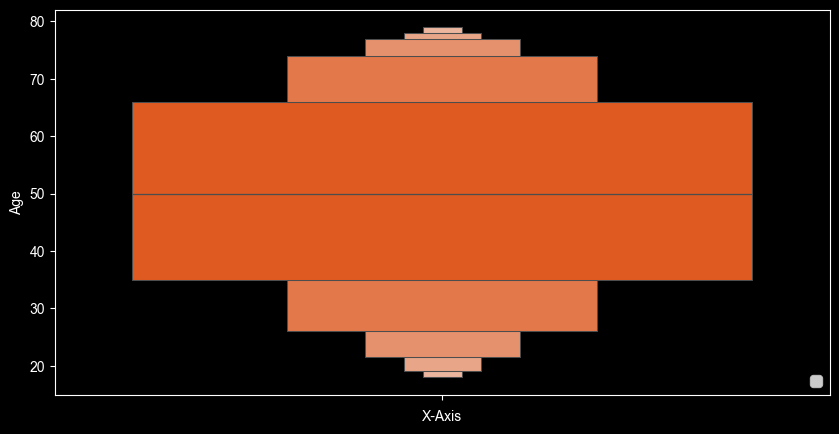

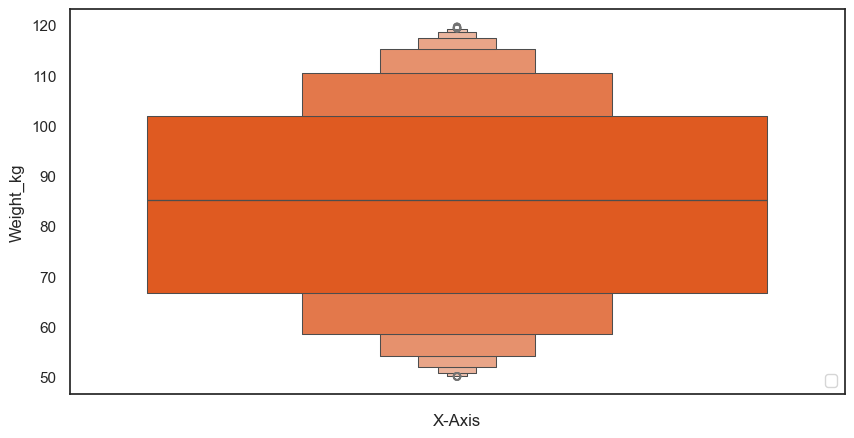

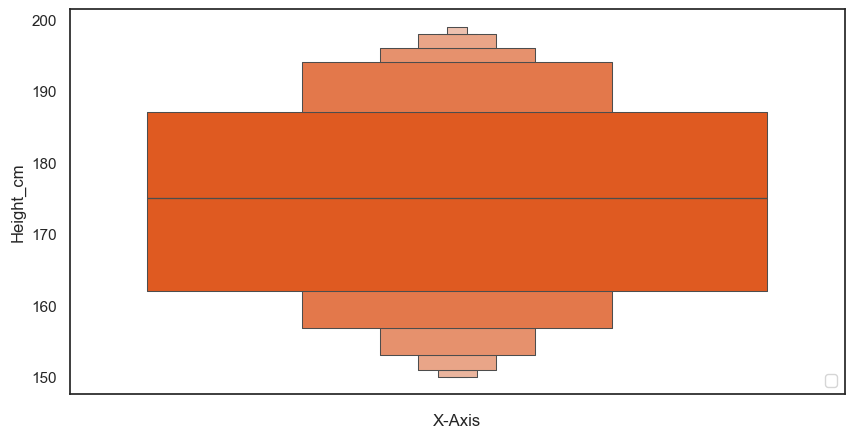

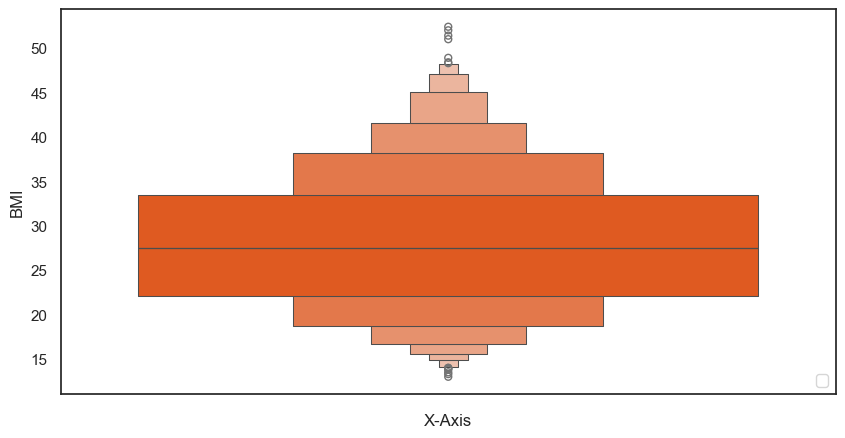

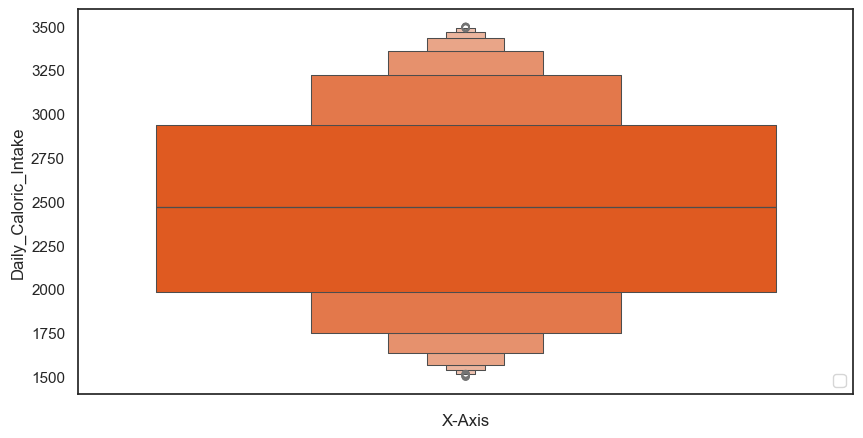

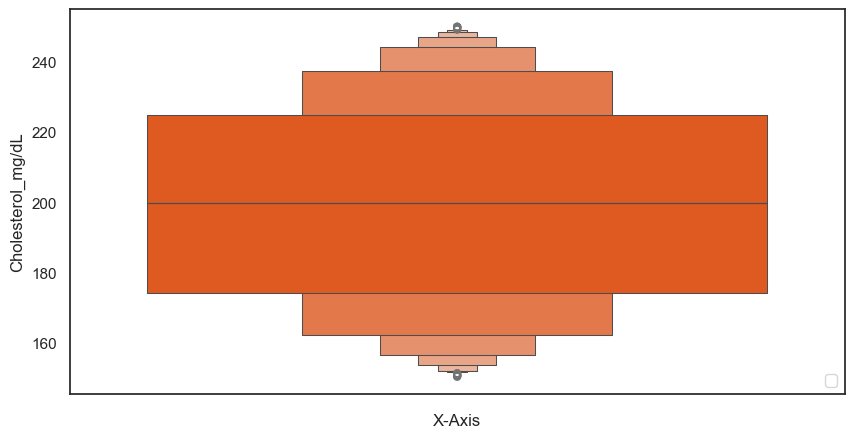

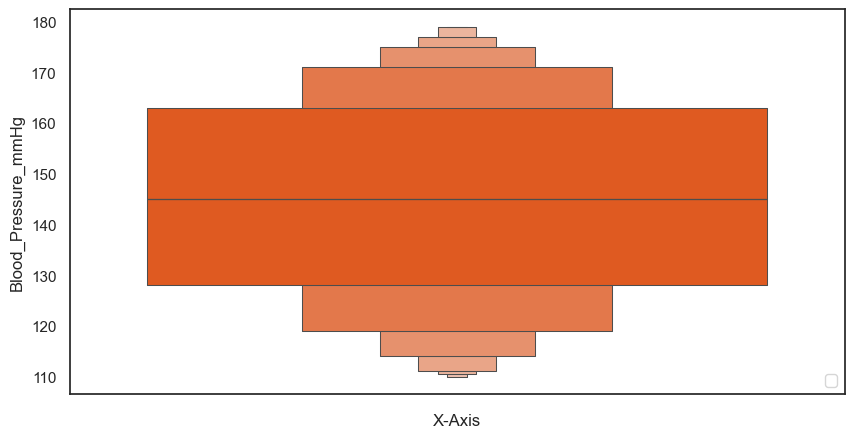

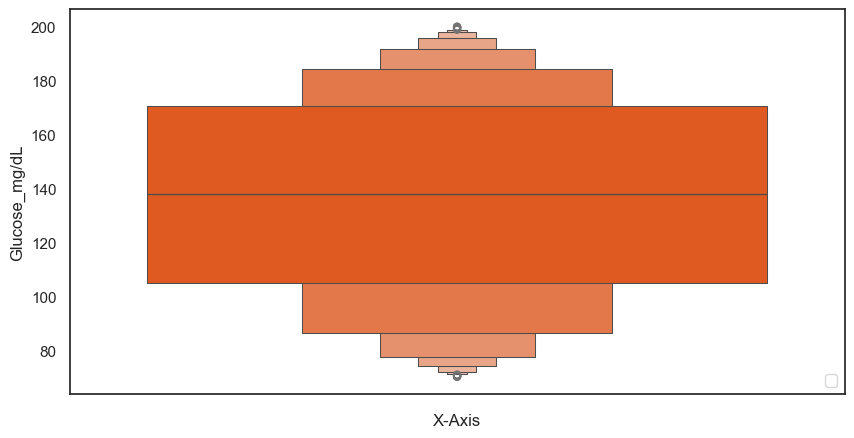

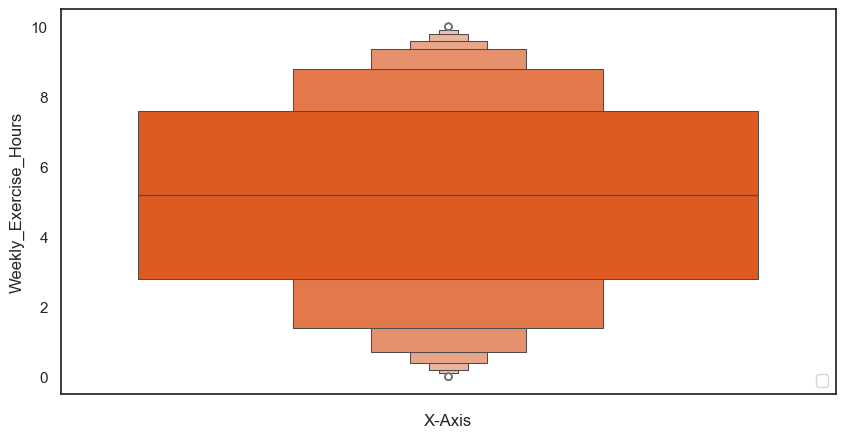

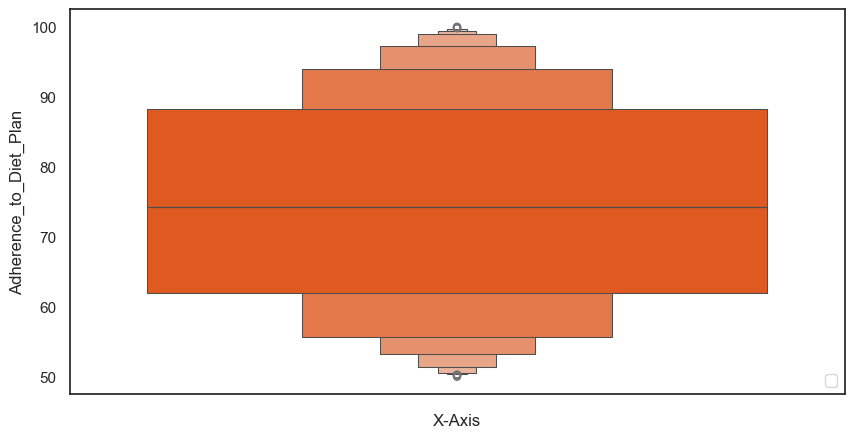

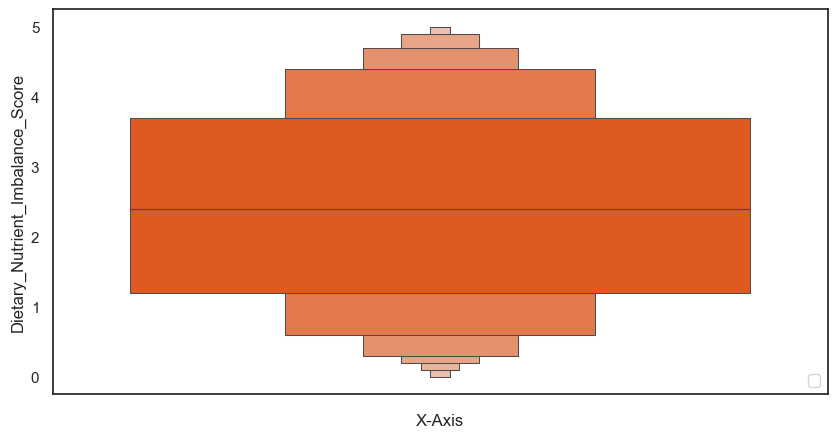

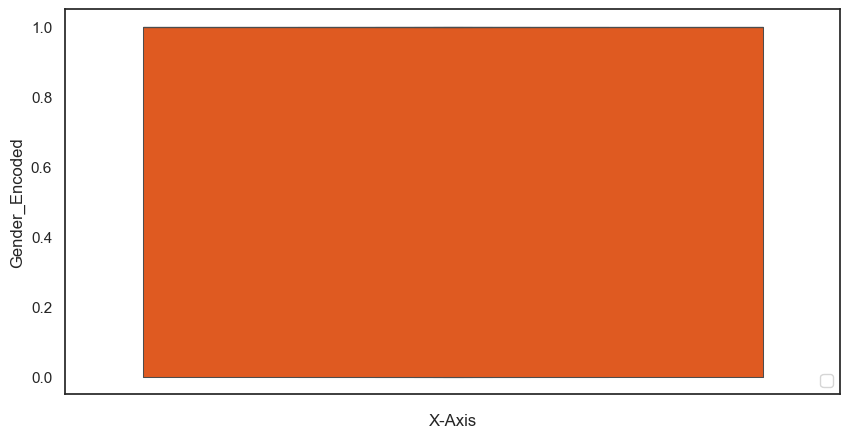

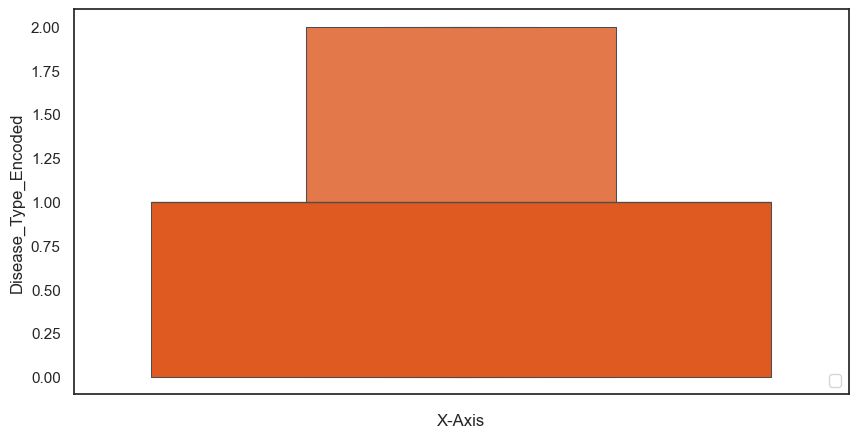

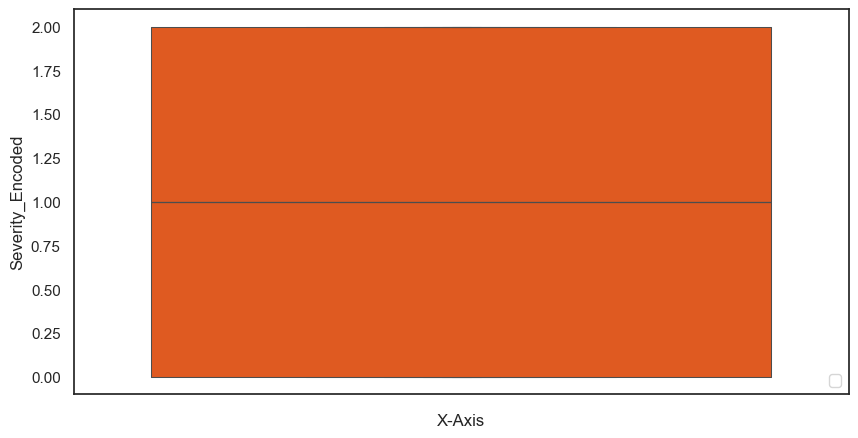

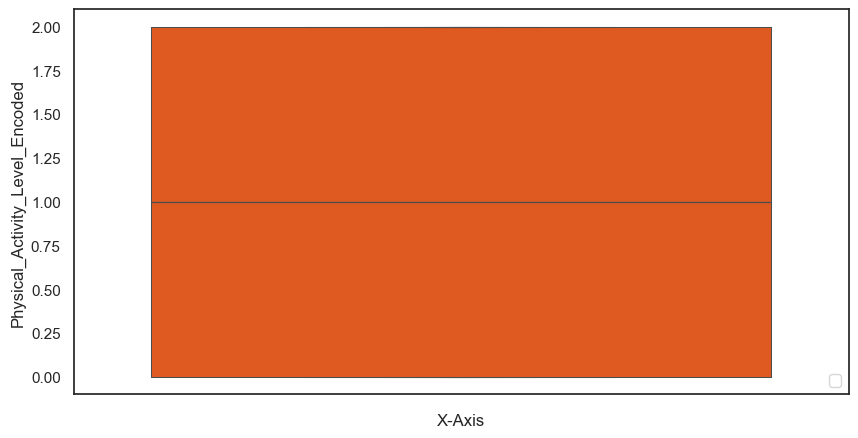

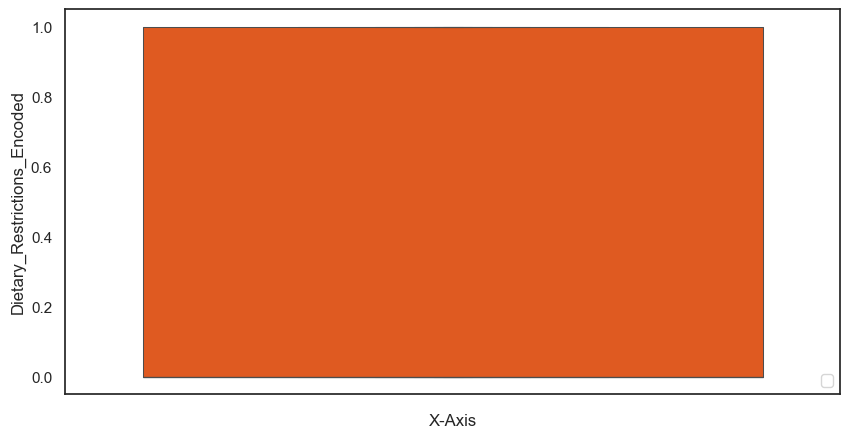

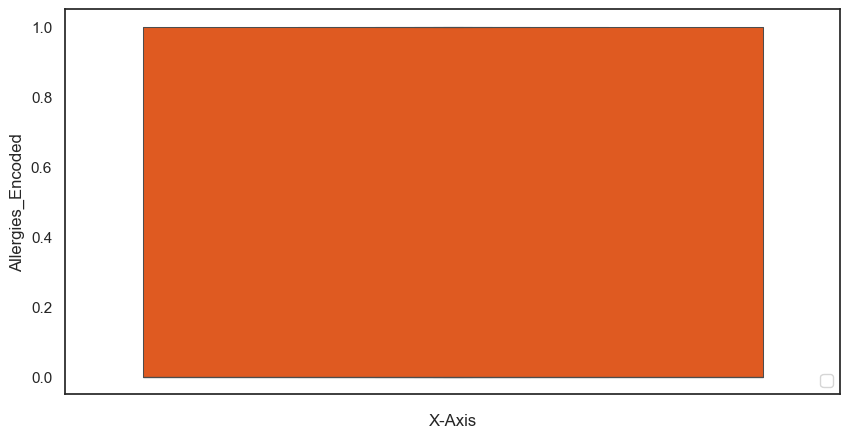

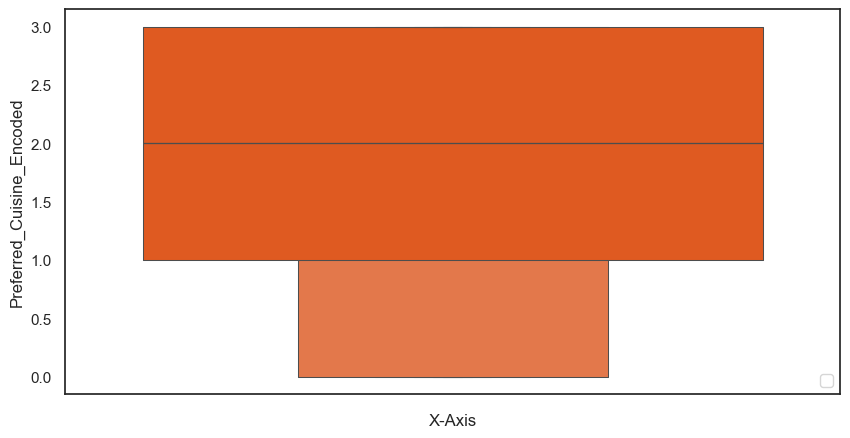

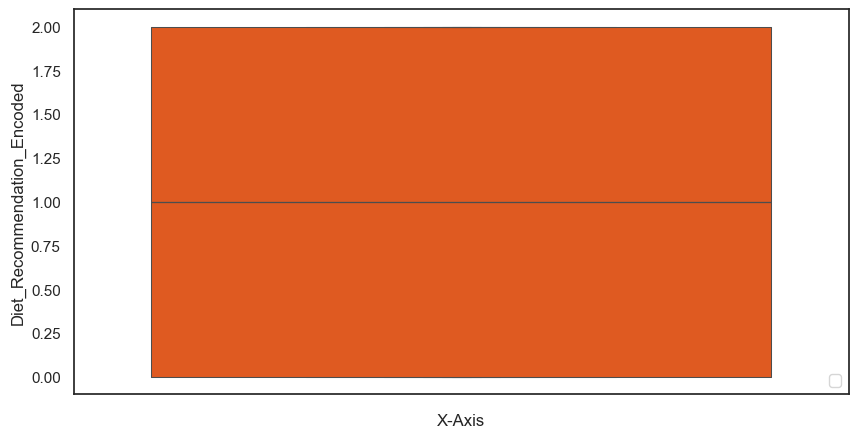

In [28]:
for each_col1 in df3.columns:
    plt.figure(figsize=(10,5))
    plt.subplot()
    sns.set_theme(style='white')
    sns.boxenplot(df3[each_col1],color='#ff4d01')
    plt.xlabel("X-Axis")
    plt.ylabel(each_col1)


    plt.legend(loc="lower right")
    plt.subplots_adjust(wspace=2,hspace=2)
    plt.show()
    

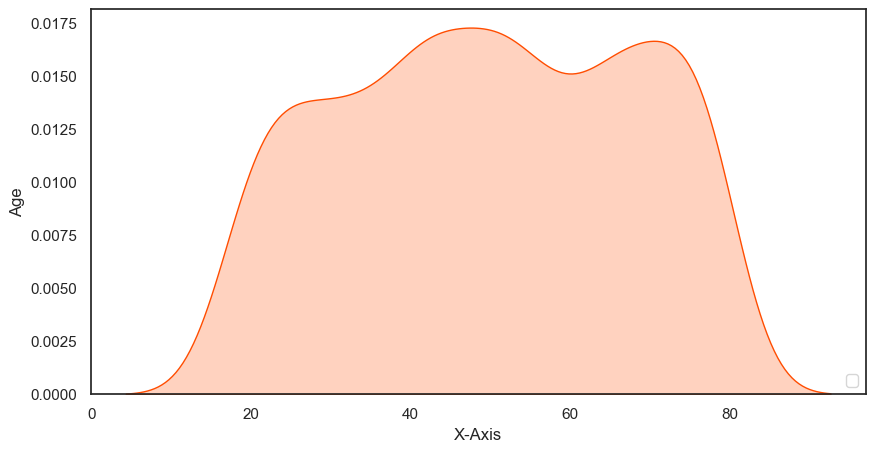

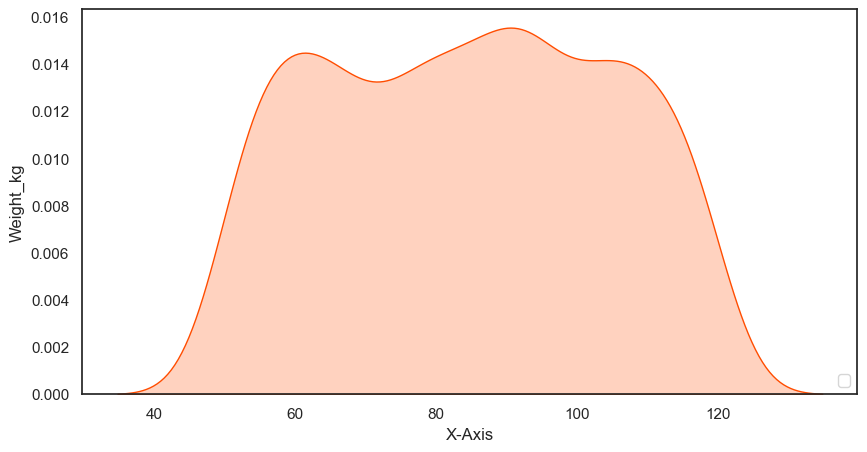

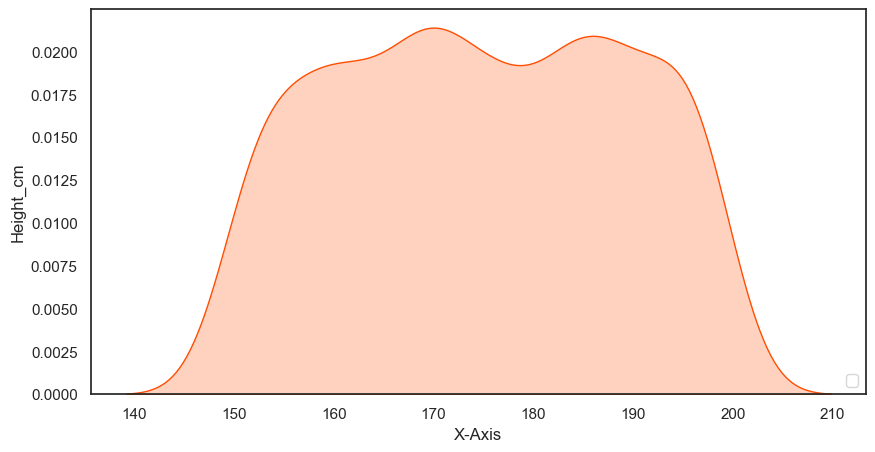

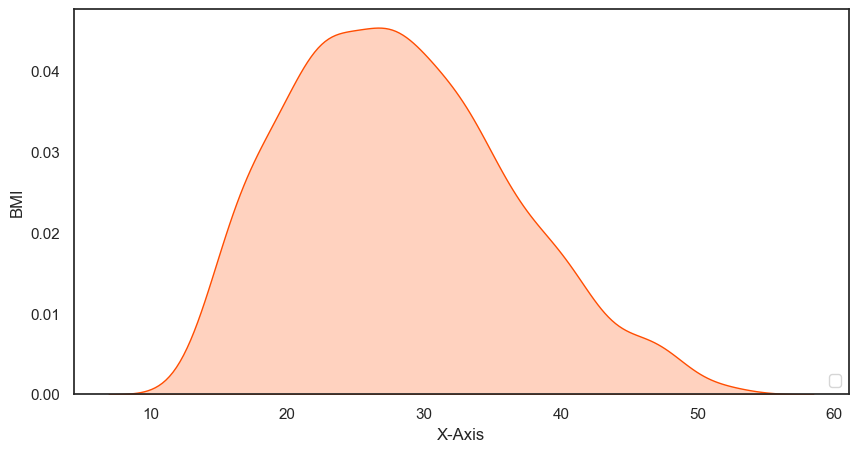

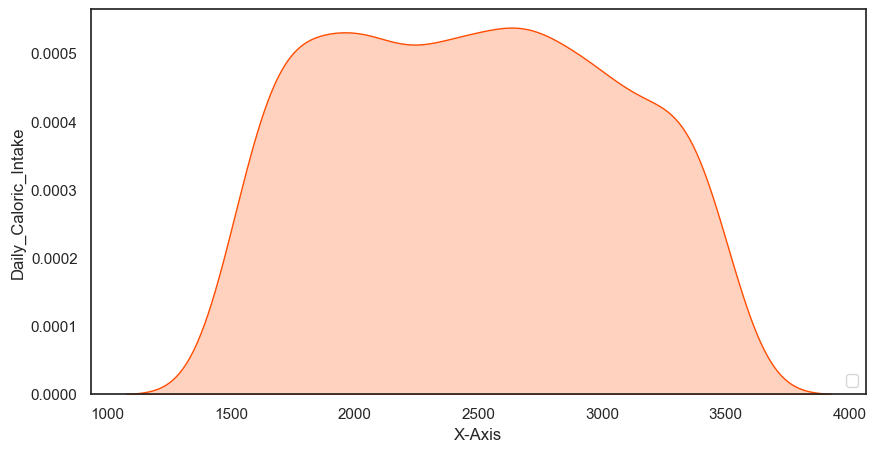

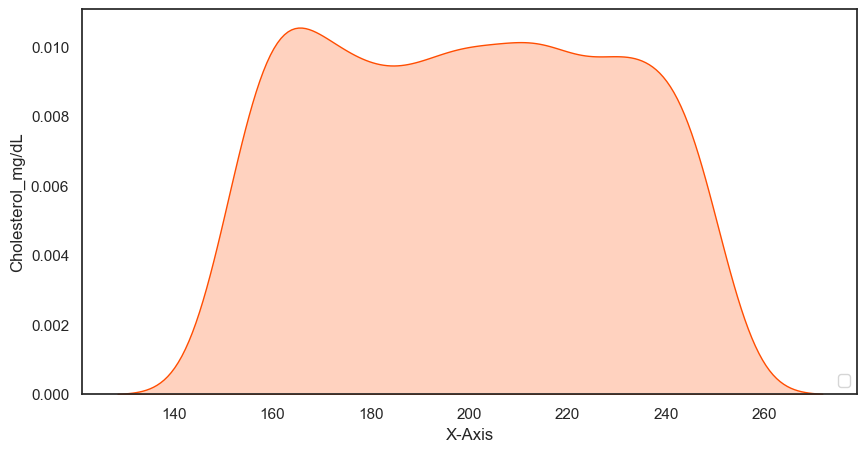

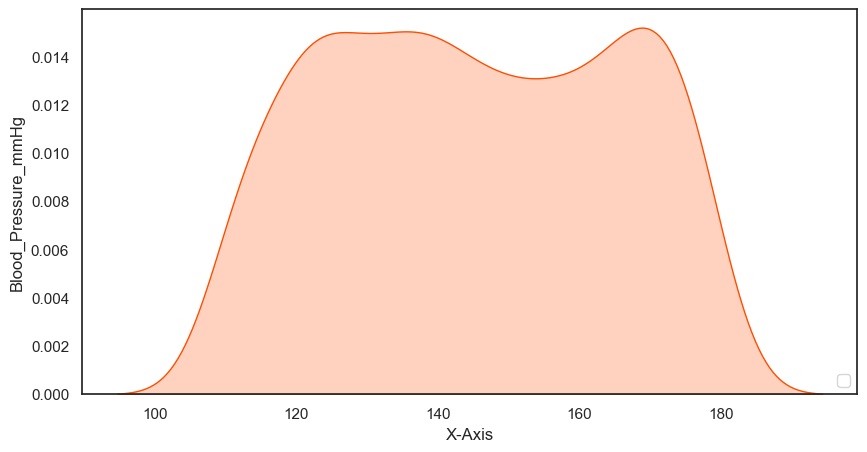

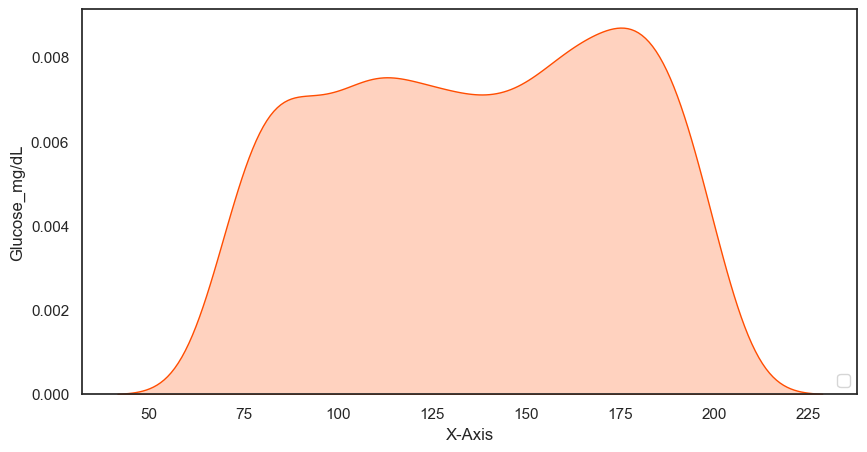

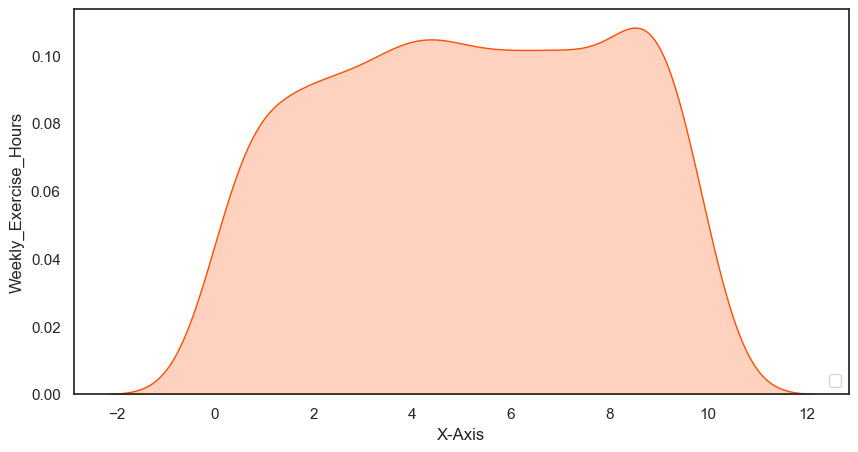

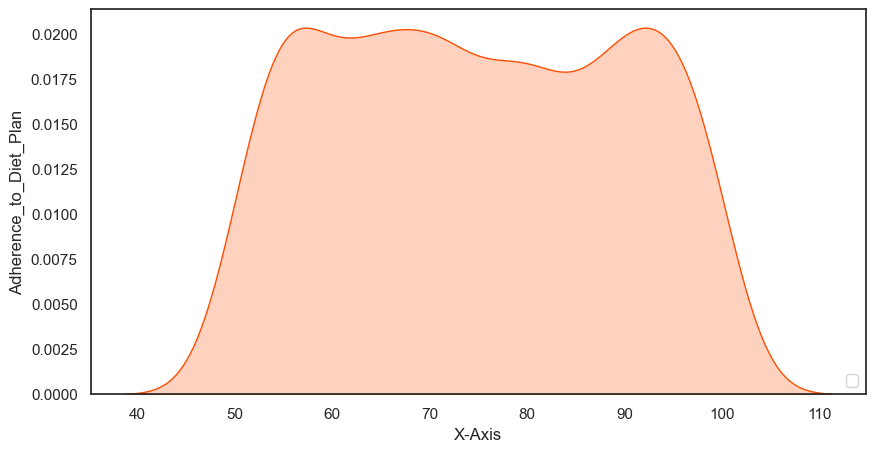

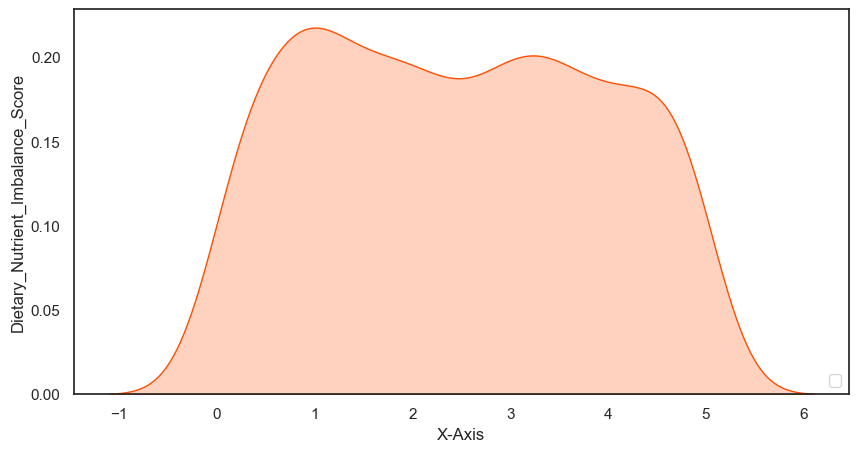

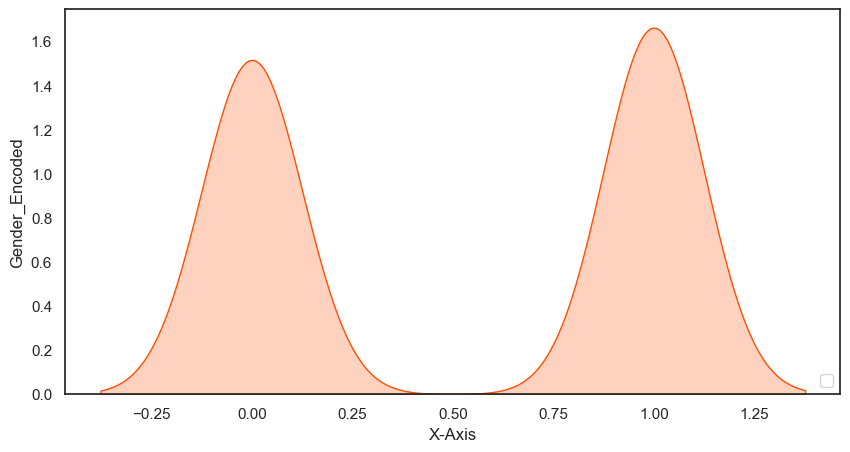

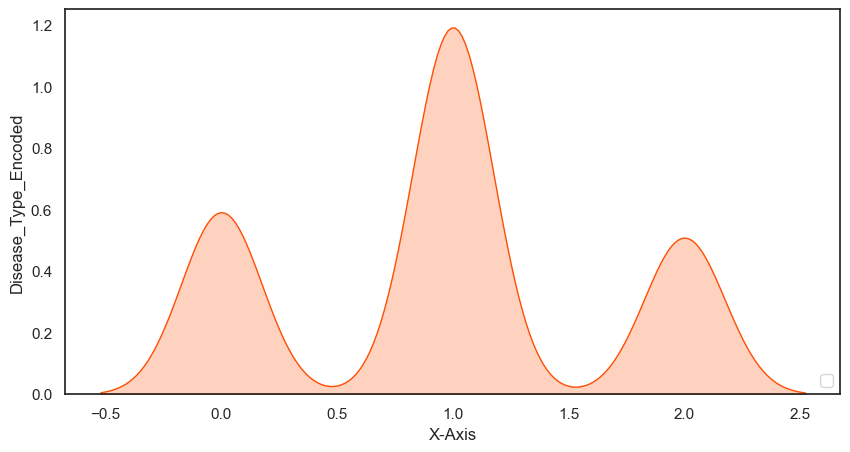

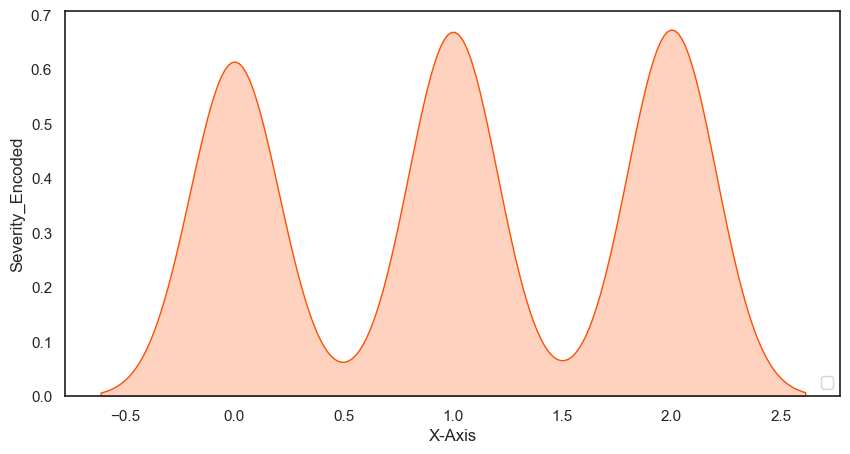

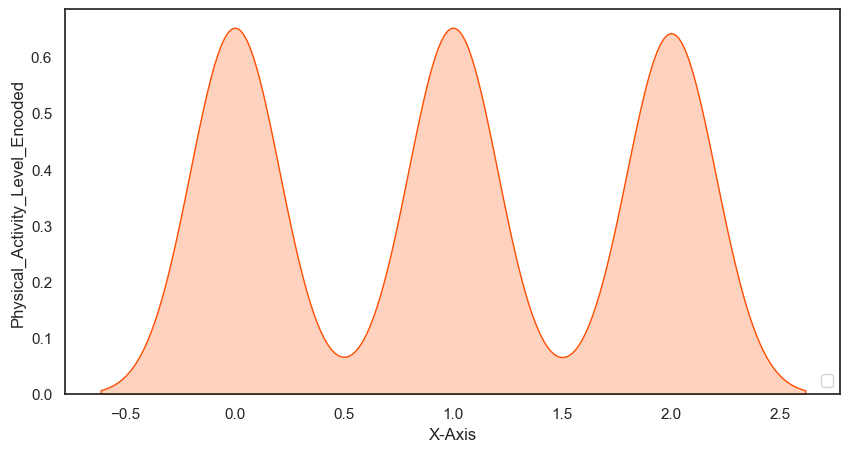

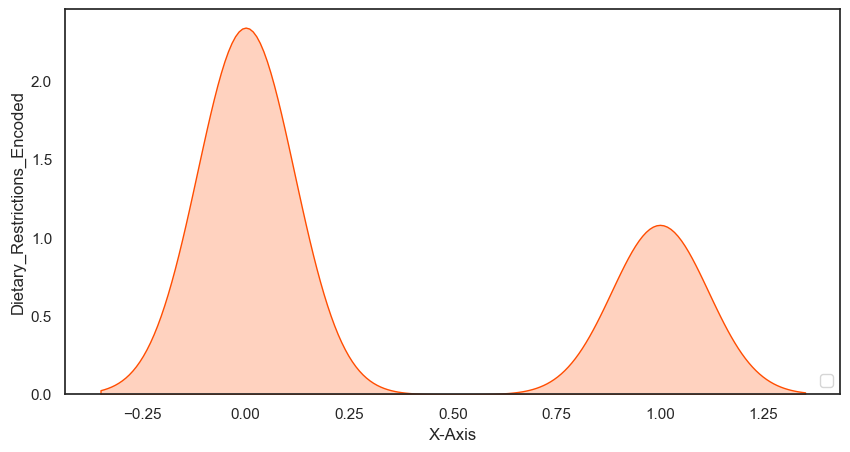

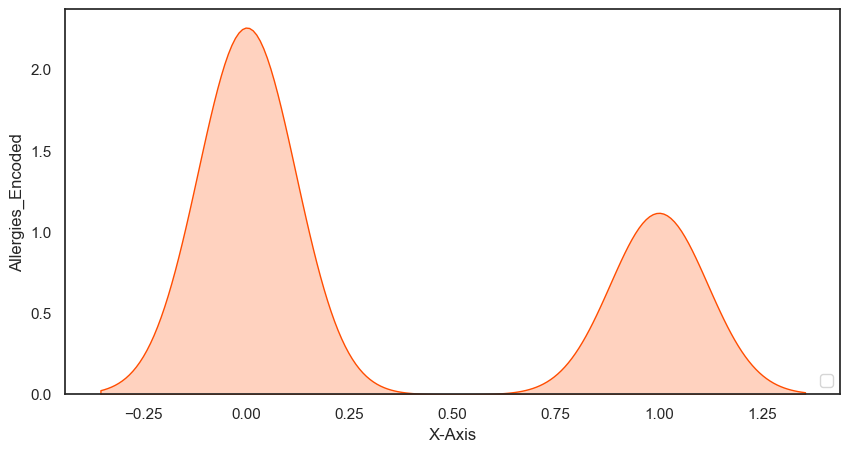

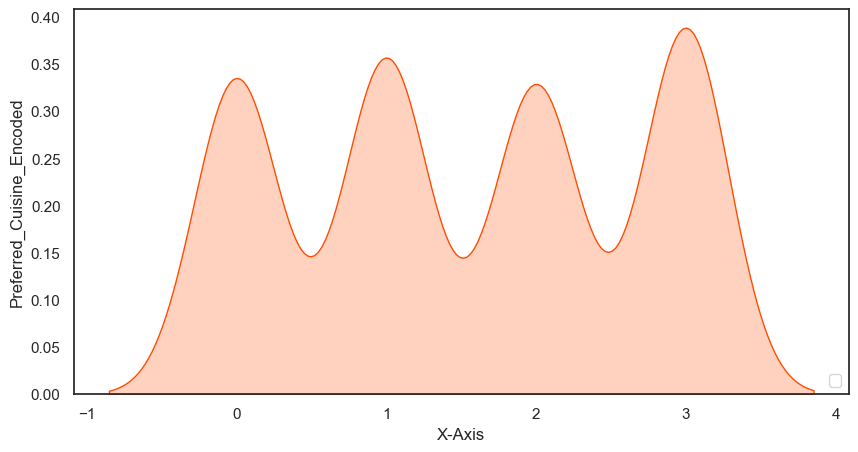

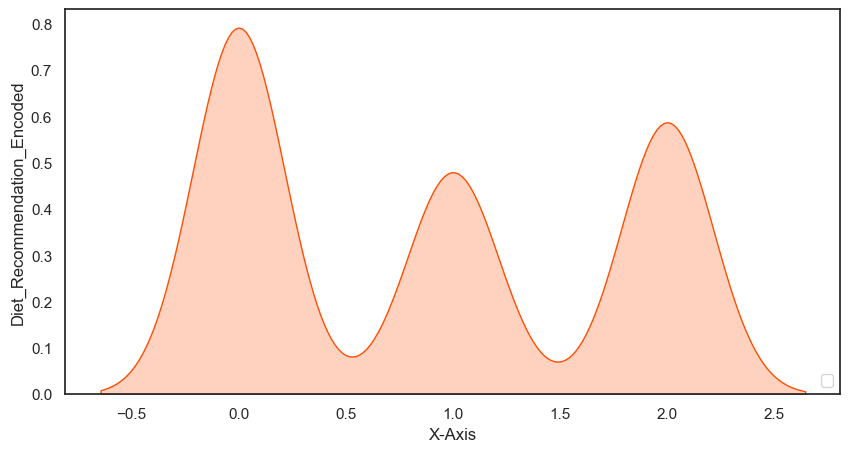

In [29]:
for each_col1 in df3.columns:
    plt.figure(figsize=(10,5))
    plt.subplot()
    sns.set_theme(style='white')
    sns.kdeplot(df3[each_col1],fill=True,color='#ff4d01')
    plt.xlabel("X-Axis")
    plt.ylabel(each_col1)


    plt.legend(loc="lower right")
    plt.subplots_adjust(wspace=2,hspace=2)
    plt.show()

In [30]:
pearson=df3.corr(method='pearson').round(2)
pearson

,Age,Weight_kg,Height_cm,BMI,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Gender_Encoded,Disease_Type_Encoded,Severity_Encoded,Physical_Activity_Level_Encoded,Dietary_Restrictions_Encoded,Allergies_Encoded,Preferred_Cuisine_Encoded,Diet_Recommendation_Encoded
Age,1.00,0.04,0.01,0.04,-0.01,-0.01,0.03,-0.02,-0.01,0.02,0.01,0.04,-0.03,0.02,0.01,0.01,0.01,0.02,0.04
Weight_kg,0.04,1.00,0.05,0.80,-0.07,-0.00,0.02,0.03,0.02,-0.05,-0.03,-0.05,-0.04,-0.03,-0.01,-0.01,0.08,0.06,-0.00
Height_cm,0.01,0.05,1.00,-0.53,0.03,-0.04,0.01,-0.03,-0.07,0.04,0.02,-0.02,0.05,0.03,0.05,0.01,0.07,0.01,-0.08
BMI,0.04,0.80,-0.53,1.00,-0.07,0.02,0.01,0.04,0.06,-0.06,-0.04,-0.03,-0.06,-0.04,-0.04,-0.01,0.03,0.04,0.04
Daily_Caloric_Intake,-0.01,-0.07,0.03,-0.07,1.00,0.01,0.03,-0.05,0.02,-0.00,0.01,-0.03,0.00,0.01,0.08,-0.03,0.01,-0.02,0.01
Cholesterol_mg/dL,-0.01,-0.00,-0.04,0.02,0.01,1.00,-0.04,0.04,-0.09,0.06,0.00,0.02,-0.03,0.04,-0.01,-0.00,0.03,0.04,0.05
Blood_Pressure_mmHg,0.03,0.02,0.01,0.01,0.03,-0.04,1.00,0.05,0.03,-0.04,0.01,-0.01,0.04,0.05,0.06,-0.05,-0.03,-0.02,-0.02
Glucose_mg/dL,-0.02,0.03,-0.03,0.04,-0.05,0.04,0.05,1.00,-0.02,0.06,0.01,-0.02,-0.02,0.02,0.01,-0.03,-0.02,0.01,0.00
Weekly_Exercise_Hours,-0.01,0.02,-0.07,0.06,0.02,-0.09,0.03,-0.02,1.00,0.02,0.03,-0.02,-0.01,0.00,0.03,0.04,-0.01,-0.07,0.07
Adherence_to_Diet_Plan,0.02,-0.05,0.04,-0.06,-0.00,0.06,-0.04,0.06,0.02,1.00,-0.02,-0.04,0.01,0.02,-0.05,-0.03,-0.03,0.04,-0.00


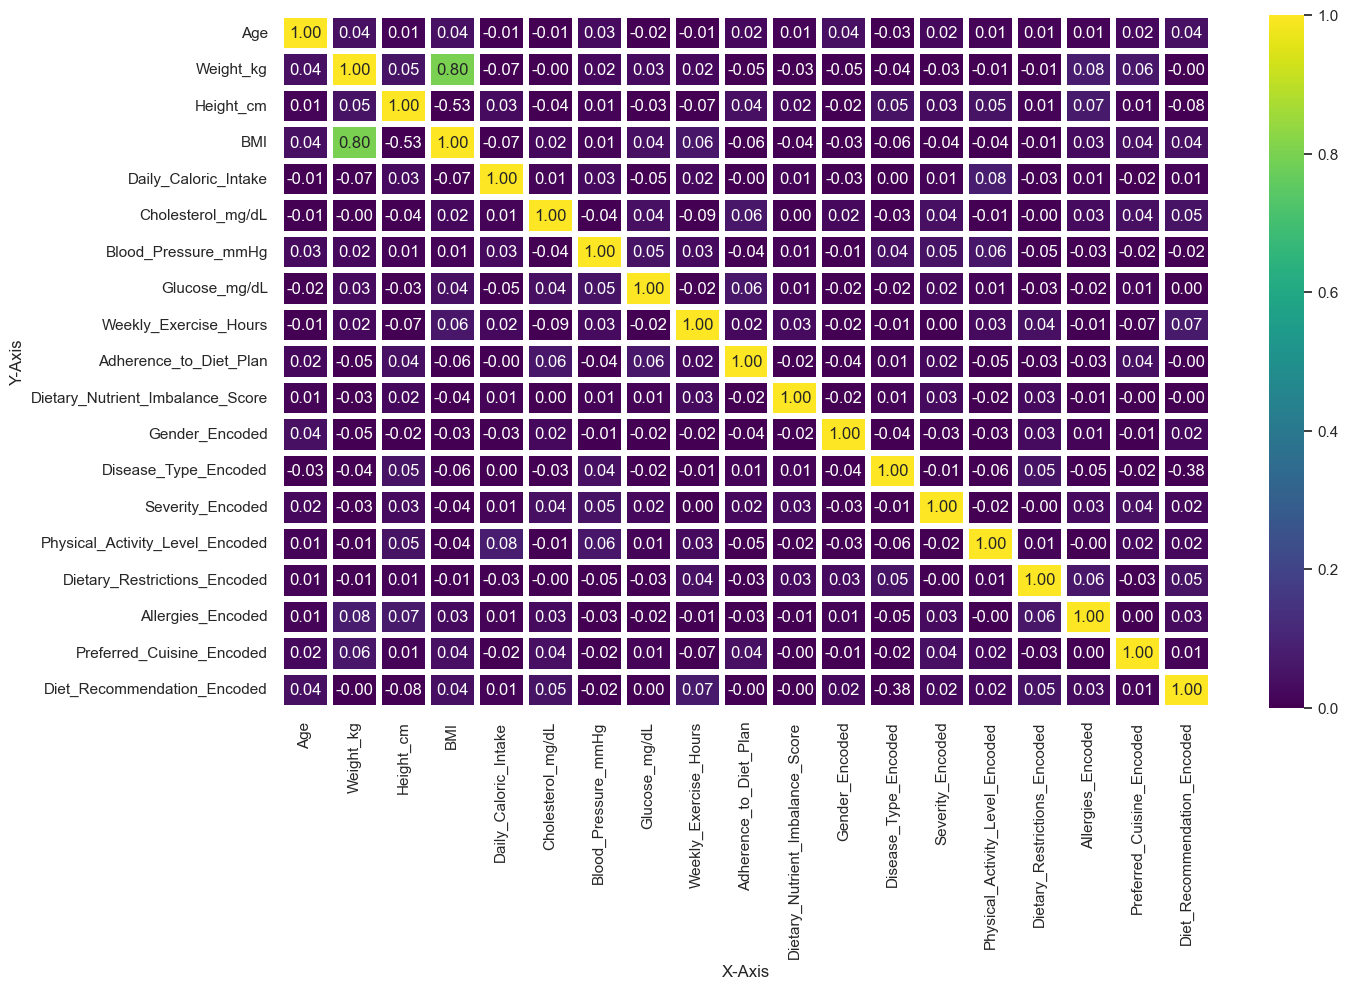

In [31]:
plt.figure(figsize=(15,9))
sns.set_theme(style='white')
sns.heatmap(pearson,annot=True,fmt='.2f',linewidths=3,cmap='viridis',vmin=0,vmax=1)
plt.xlabel("X-Axis")
plt.ylabel('Y-Axis')
plt.savefig("heatmap_pearson.png",dpi=100)
plt.show()

In [32]:
spearman=df3.corr(method='spearman').round(2)
spearman

,Age,Weight_kg,Height_cm,BMI,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Gender_Encoded,Disease_Type_Encoded,Severity_Encoded,Physical_Activity_Level_Encoded,Dietary_Restrictions_Encoded,Allergies_Encoded,Preferred_Cuisine_Encoded,Diet_Recommendation_Encoded
Age,1.00,0.04,0.01,0.03,-0.01,-0.01,0.03,-0.02,-0.01,0.02,0.01,0.03,-0.03,0.02,0.01,0.01,0.01,0.02,0.04
Weight_kg,0.04,1.00,0.05,0.82,-0.07,-0.01,0.02,0.03,0.02,-0.05,-0.04,-0.05,-0.04,-0.03,-0.01,-0.01,0.08,0.06,-0.00
Height_cm,0.01,0.05,1.00,-0.51,0.03,-0.04,0.01,-0.02,-0.07,0.04,0.02,-0.02,0.05,0.03,0.05,0.01,0.07,0.01,-0.08
BMI,0.03,0.82,-0.51,1.00,-0.07,0.02,0.01,0.03,0.07,-0.07,-0.03,-0.03,-0.07,-0.04,-0.04,-0.01,0.03,0.04,0.05
Daily_Caloric_Intake,-0.01,-0.07,0.03,-0.07,1.00,0.01,0.03,-0.05,0.02,-0.00,0.01,-0.03,0.00,0.01,0.08,-0.03,0.01,-0.02,0.01
Cholesterol_mg/dL,-0.01,-0.01,-0.04,0.02,0.01,1.00,-0.03,0.03,-0.09,0.07,0.00,0.02,-0.03,0.03,-0.01,-0.00,0.03,0.04,0.05
Blood_Pressure_mmHg,0.03,0.02,0.01,0.01,0.03,-0.03,1.00,0.05,0.03,-0.04,0.01,-0.01,0.04,0.05,0.06,-0.05,-0.03,-0.02,-0.02
Glucose_mg/dL,-0.02,0.03,-0.02,0.03,-0.05,0.03,0.05,1.00,-0.01,0.06,0.01,-0.02,-0.02,0.03,0.01,-0.03,-0.02,0.01,0.00
Weekly_Exercise_Hours,-0.01,0.02,-0.07,0.07,0.02,-0.09,0.03,-0.01,1.00,0.02,0.02,-0.02,-0.01,0.00,0.03,0.04,-0.01,-0.07,0.07
Adherence_to_Diet_Plan,0.02,-0.05,0.04,-0.07,-0.00,0.07,-0.04,0.06,0.02,1.00,-0.02,-0.04,0.01,0.02,-0.05,-0.04,-0.03,0.04,-0.01


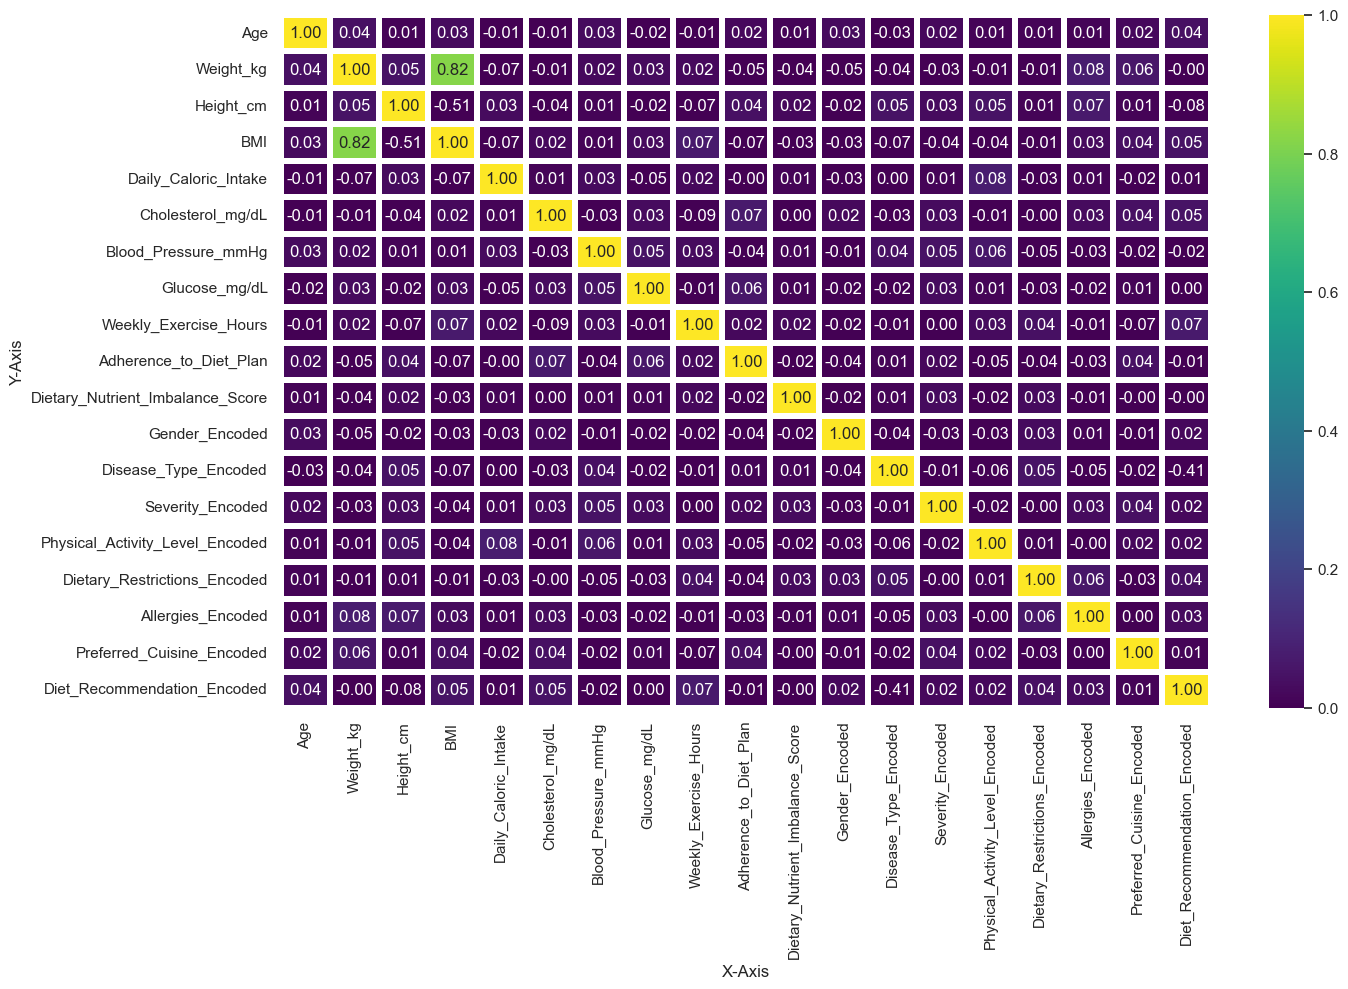

In [33]:
plt.figure(figsize=(15,9))
sns.set_theme(style='white')
sns.heatmap(spearman,annot=True,fmt='.2f',linewidths=3,cmap='viridis',vmin=0,vmax=1)
plt.xlabel("X-Axis")
plt.ylabel('Y-Axis')
plt.savefig("heatmap_spearman.png",dpi=100)
plt.show()

In [34]:
df3.isna().sum()

Age                                 0
Weight_kg                           0
Height_cm                           0
BMI                                 0
Daily_Caloric_Intake                0
Cholesterol_mg/dL                   0
Blood_Pressure_mmHg                 0
Glucose_mg/dL                       0
Weekly_Exercise_Hours               0
Adherence_to_Diet_Plan              0
Dietary_Nutrient_Imbalance_Score    0
Gender_Encoded                      0
Disease_Type_Encoded                0
Severity_Encoded                    0
Physical_Activity_Level_Encoded     0
Dietary_Restrictions_Encoded        0
Allergies_Encoded                   0
Preferred_Cuisine_Encoded           0
Diet_Recommendation_Encoded         0
dtype: int64

In [35]:
list(df3.columns)

['Age',
 'Weight_kg',
 'Height_cm',
 'BMI',
 'Daily_Caloric_Intake',
 'Cholesterol_mg/dL',
 'Blood_Pressure_mmHg',
 'Glucose_mg/dL',
 'Weekly_Exercise_Hours',
 'Adherence_to_Diet_Plan',
 'Dietary_Nutrient_Imbalance_Score',
 'Gender_Encoded',
 'Disease_Type_Encoded',
 'Severity_Encoded',
 'Physical_Activity_Level_Encoded',
 'Dietary_Restrictions_Encoded',
 'Allergies_Encoded',
 'Preferred_Cuisine_Encoded',
 'Diet_Recommendation_Encoded']

In [36]:
class AnomoliesDetection:
    def __init__(self,data):
        self.data=data
    def IQRMethod(self,col):
        Q1=self.data[col].quantile(0.25)
        Q3=self.data[col].quantile(0.75)
        IQR=Q3-Q1
        left_region=Q1-1.5*IQR
        right_region=Q3+1.5*IQR
        mask=(self.data[col]<left_region) | (self.data[col]>right_region)
        ano_index=self.data[col][mask].index.tolist()
        ano_data=self.data[col][mask].tolist()
        return list(ano_index),list(ano_data)
    
    def ThreeSigmaMethod(self,col1):
        mean_value=sts.mean(self.data[col1])
        std_dev=sts.stdev(self.data[col1])
        cutoff=3*std_dev
        left_region1=mean_value-cutoff
        right_region1=mean_value+cutoff
        mask1=(self.data[col1]<left_region1) | (self.data[col1]>right_region1)
        ano_index1=self.data[col1][mask1].index.tolist()
        ano_data1=self.data[col1][mask1].tolist()
        return list(ano_index1),list(ano_data1)

num_cols=df3.select_dtypes(include='number',exclude='object').columns
print(df3.shape)
instance_anomolies=AnomoliesDetection(df3)
store_index=set()

for each_colos in num_cols:
    ano_index1,ano_data1=instance_anomolies.IQRMethod(each_colos)
    ano_index2,ano_data2=instance_anomolies.ThreeSigmaMethod(each_colos)
    if ano_index1 and ano_index2:
        print("IQR Method results")
        print(f"each col is -- >{each_colos} -- index is {ano_index1} and data is {ano_data1}")
        import time
        time.sleep(2)
        print("storing into set those indexs")
        store_index.update(ano_index1)
        print("------------------")
        print("Three sigma Method")
        print(f"each cols is --> {each_colos} and index is --> {ano_index2} and data is {ano_data2}")
        print("-------------------")
    else:
        print(f" no anomolies are found {each_colos}")

print(store_index)
print("Dropping the indexes")
df3.drop(list(store_index),axis=0,inplace=True)


(1000, 19)
 no anomolies are found Age
 no anomolies are found Weight_kg
 no anomolies are found Height_cm
IQR Method results
each col is -- >BMI -- index is [323, 455, 830, 838] and data is [51.4, 51.0, 52.4, 52.0]
storing into set those indexs
------------------
Three sigma Method
each cols is --> BMI and index is --> [830] and data is [52.4]
-------------------
 no anomolies are found Daily_Caloric_Intake
 no anomolies are found Cholesterol_mg/dL
 no anomolies are found Blood_Pressure_mmHg
 no anomolies are found Glucose_mg/dL
 no anomolies are found Weekly_Exercise_Hours
 no anomolies are found Adherence_to_Diet_Plan
 no anomolies are found Dietary_Nutrient_Imbalance_Score
 no anomolies are found Gender_Encoded
 no anomolies are found Disease_Type_Encoded
 no anomolies are found Severity_Encoded
 no anomolies are found Physical_Activity_Level_Encoded
 no anomolies are found Dietary_Restrictions_Encoded
 no anomolies are found Allergies_Encoded
 no anomolies are found Preferred_Cuis

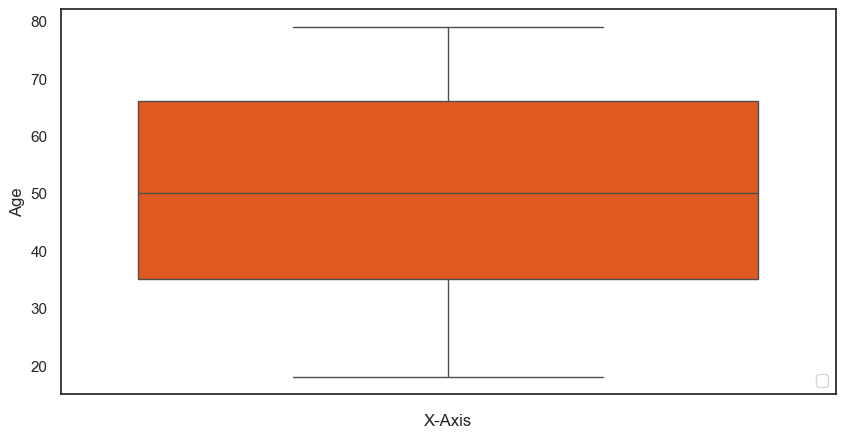

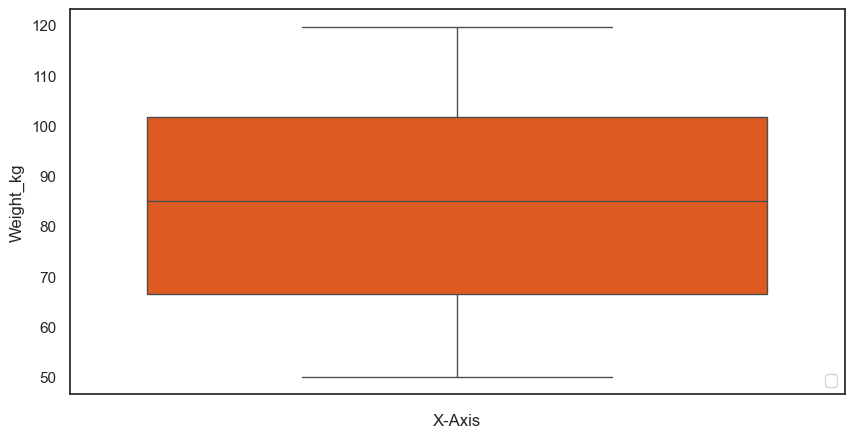

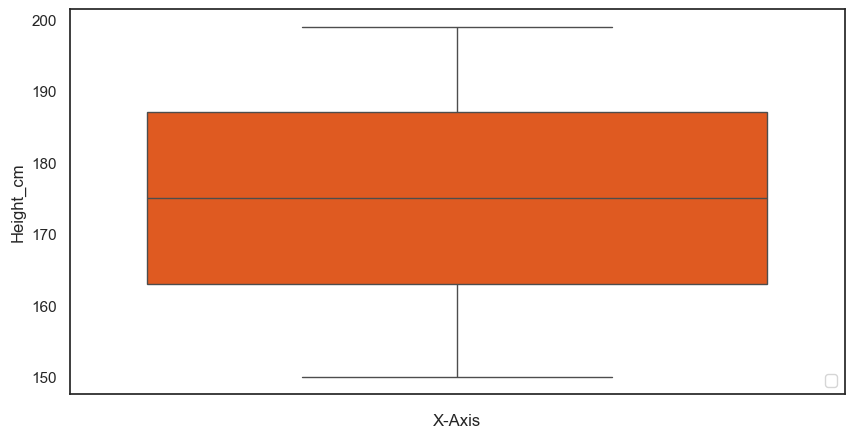

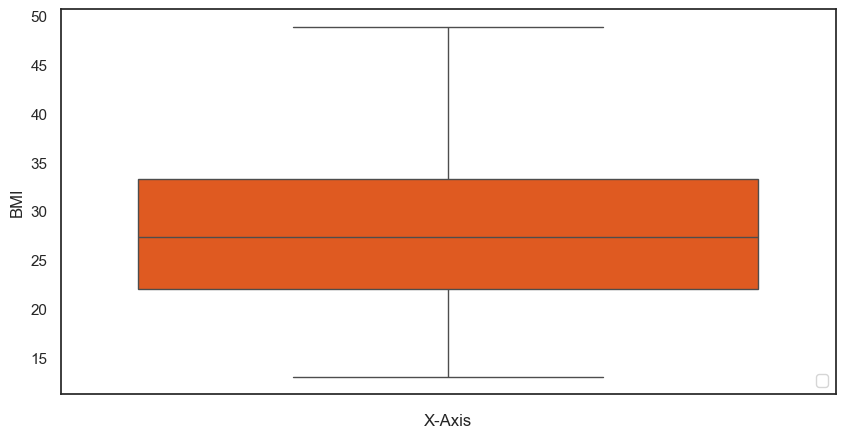

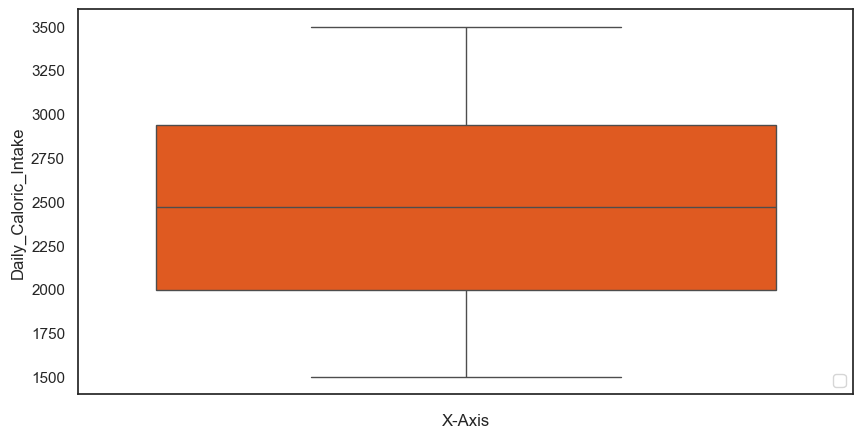

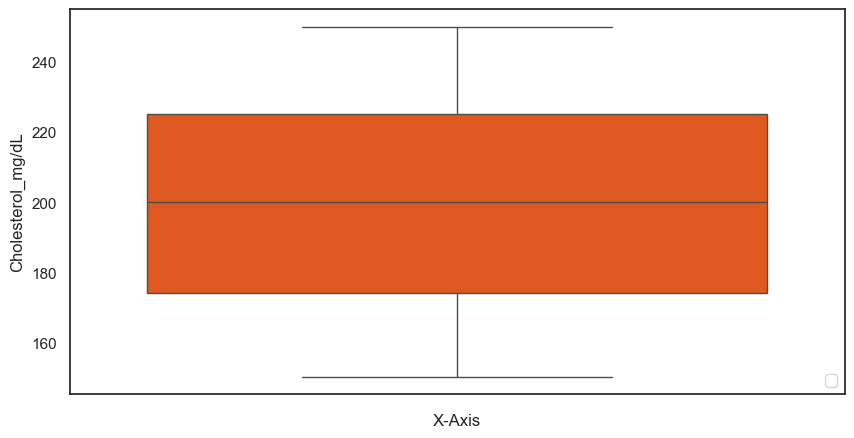

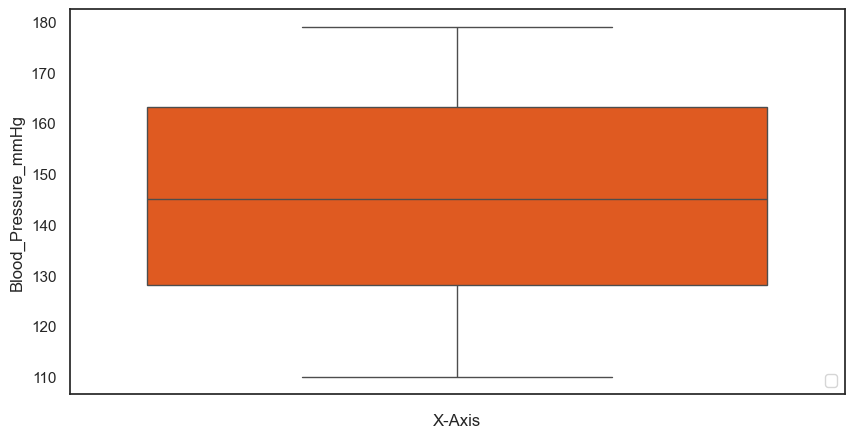

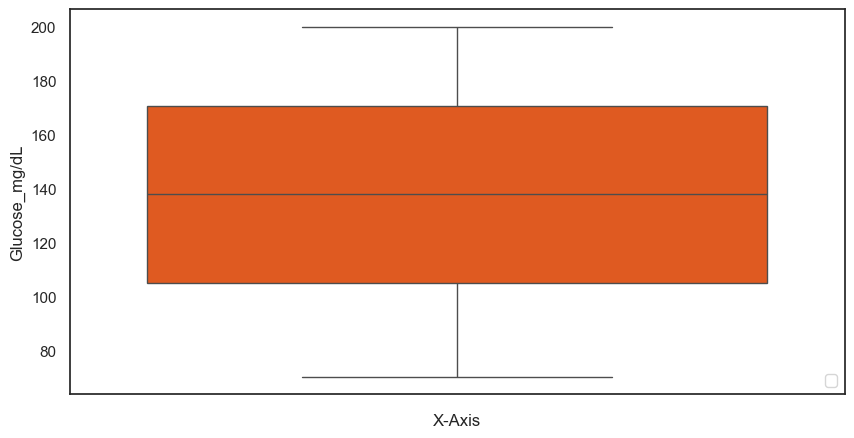

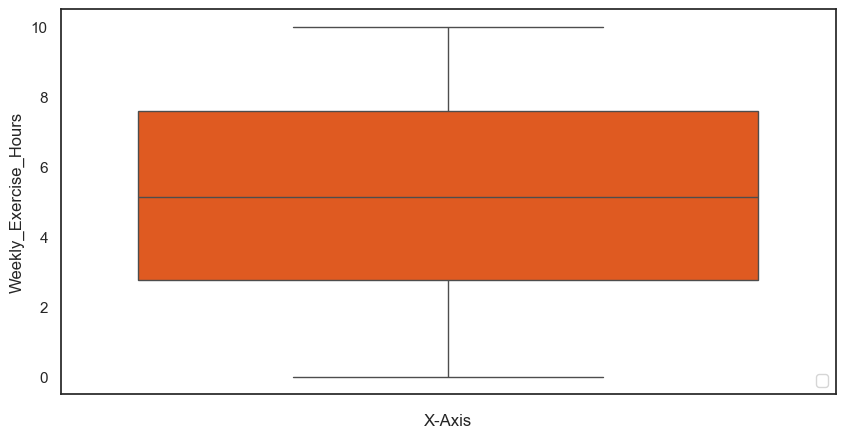

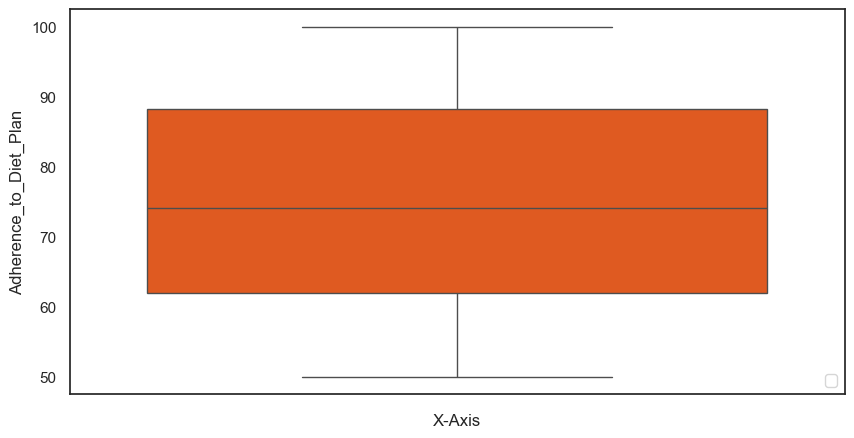

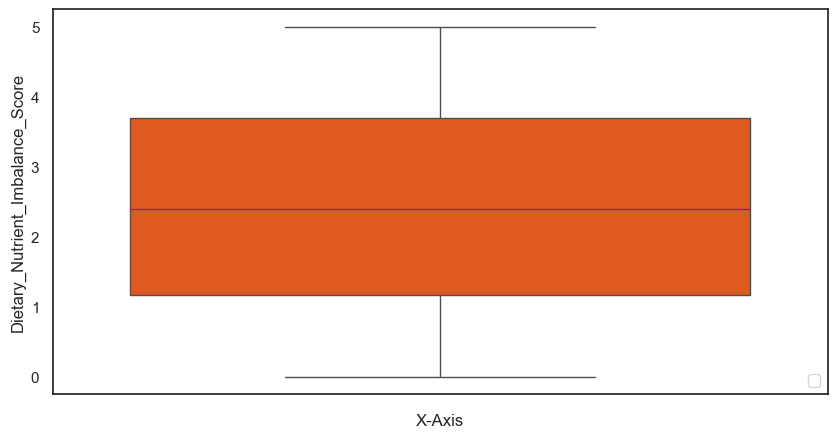

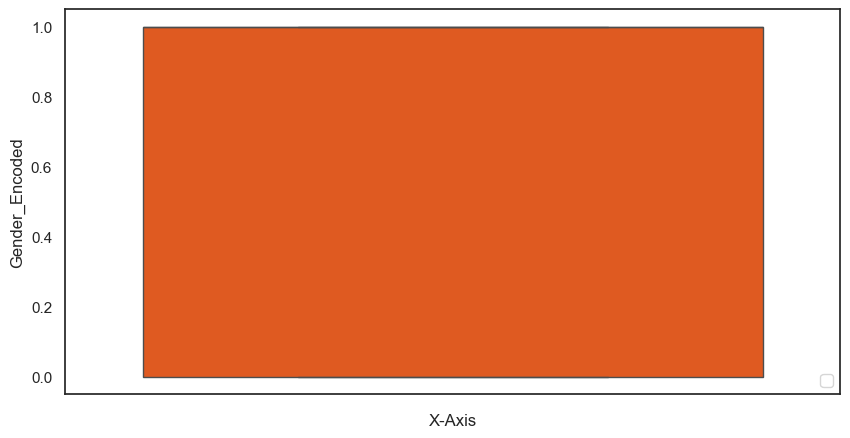

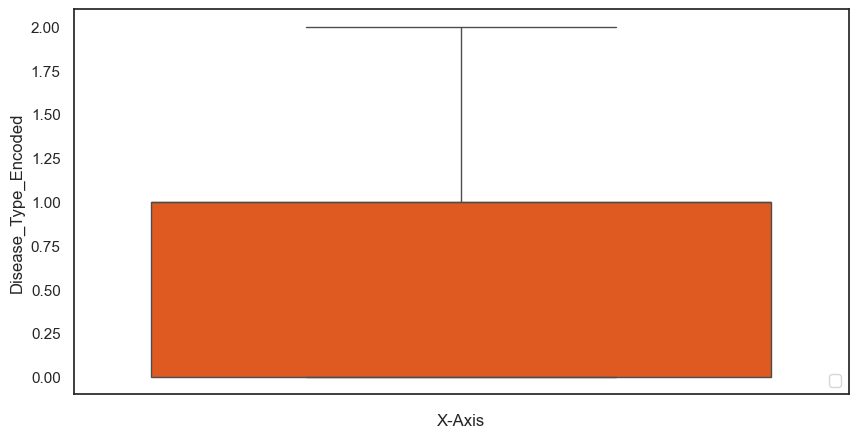

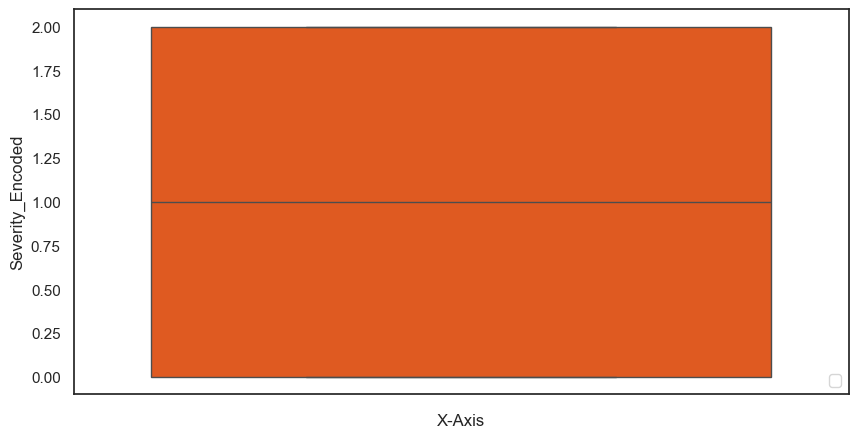

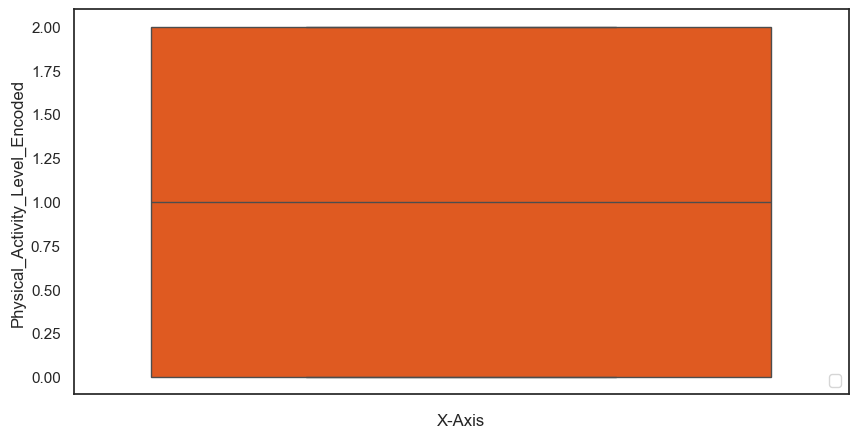

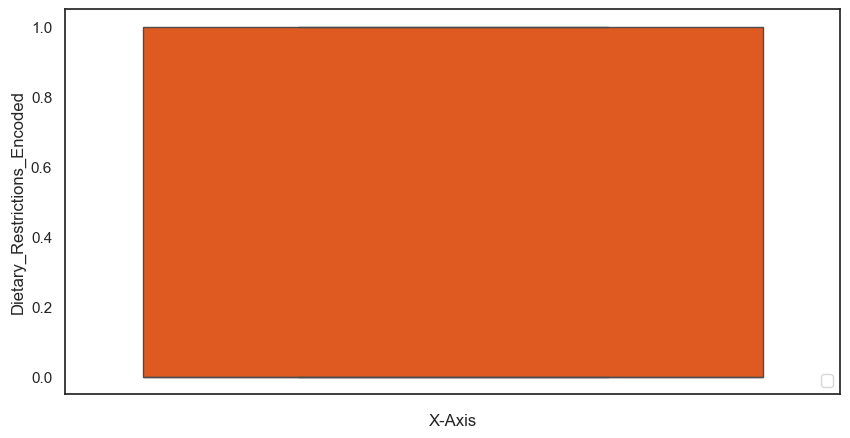

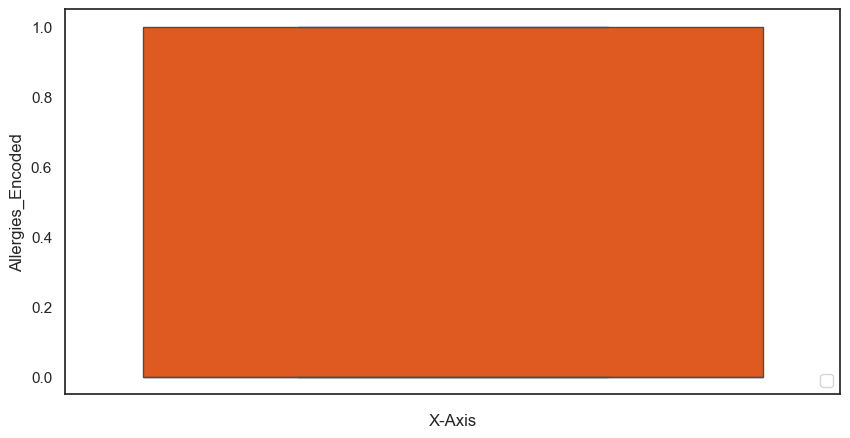

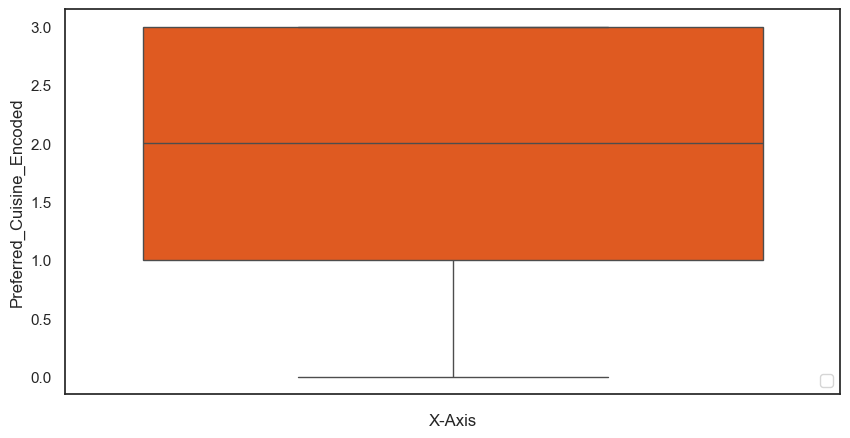

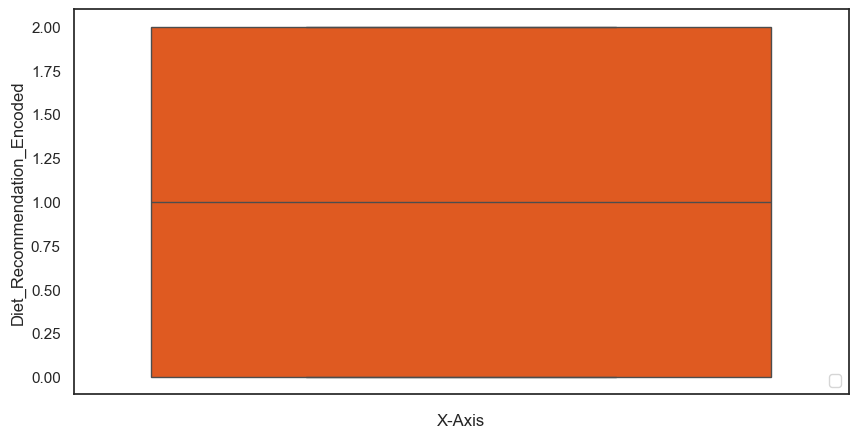

In [ ]:
for each_col1 in df3.columns:
    plt.figure(figsize=(10,5))
    plt.subplot()
    sns.set_theme(style='white')
    sns.barplot(df3[each_col1],color='#ff4d01')
    plt.xlabel("X-Axis")
    plt.ylabel(each_col1)


    plt.legend(loc="lower right")
    plt.subplots_adjust(wspace=2,hspace=2)
    plt.show()

In [38]:
df3.sample(10)

,Age,Weight_kg,Height_cm,BMI,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Gender_Encoded,Disease_Type_Encoded,Severity_Encoded,Physical_Activity_Level_Encoded,Dietary_Restrictions_Encoded,Allergies_Encoded,Preferred_Cuisine_Encoded,Diet_Recommendation_Encoded
54,20,113.7,197,29.3,1971,161.3,161,182.9,9.6,61.6,0.7,1,1,2,0,0,0,2,0
108,31,67.7,161,26.1,2019,157.7,132,112.2,1.8,87.2,0.3,0,1,0,1,0,0,2,0
581,57,78.1,196,20.3,2881,175.8,160,149.1,0.5,98.7,2.6,1,2,1,0,0,0,0,0
977,23,50.9,167,18.3,2580,162.7,116,131.1,7.7,55.7,3.4,1,2,0,1,0,0,2,0
916,54,92.2,177,29.4,2454,226.2,155,142.6,6.7,53.6,2.5,1,1,2,1,1,0,1,2
583,33,74.0,168,26.2,2651,195.8,161,194.9,3.7,94.5,2.1,0,1,1,2,1,0,1,2
592,36,97.6,176,31.5,1584,170.5,164,83.3,9.5,95.5,1.7,1,1,2,1,1,1,0,0
128,46,67.2,161,25.9,2480,225.7,121,108.0,5.1,88.2,3.0,0,1,0,0,0,1,1,2
671,49,72.2,177,23.0,2183,233.6,153,166.0,0.2,74.2,1.4,1,1,1,0,0,0,2,2
867,61,106.8,159,42.2,3009,233.0,121,149.1,1.6,67.4,5.0,1,0,0,2,0,0,3,1


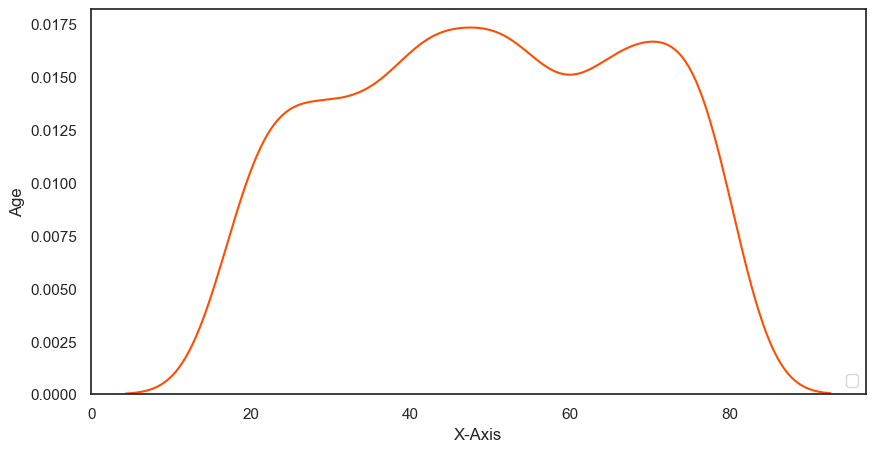

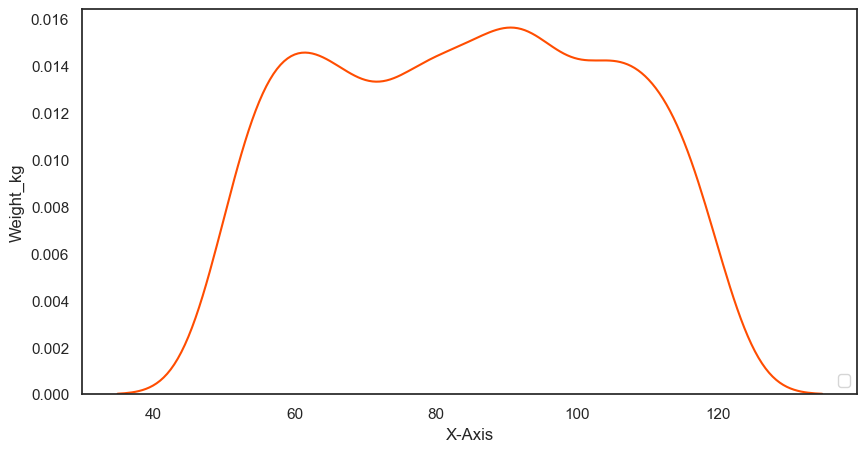

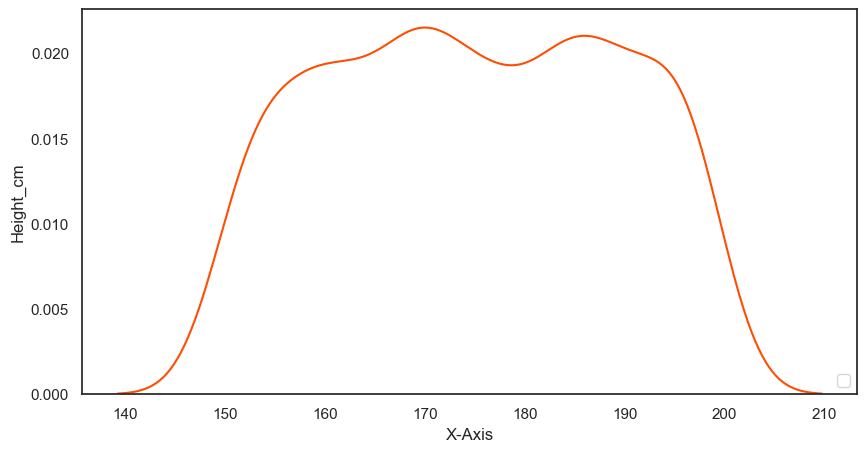

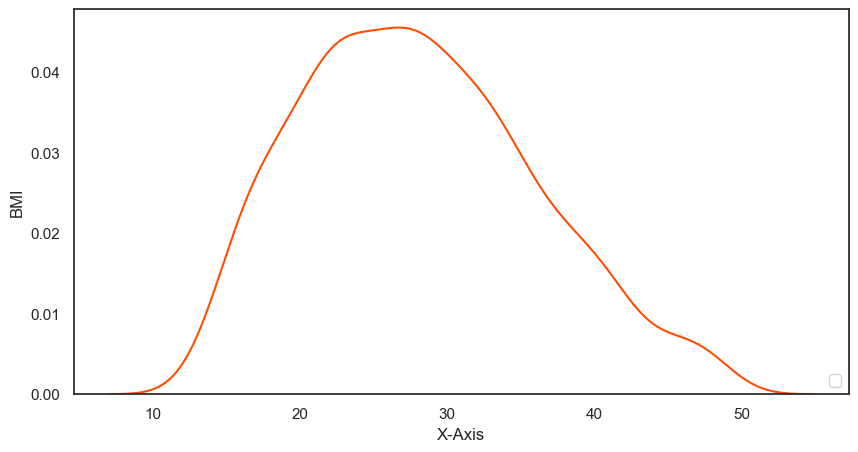

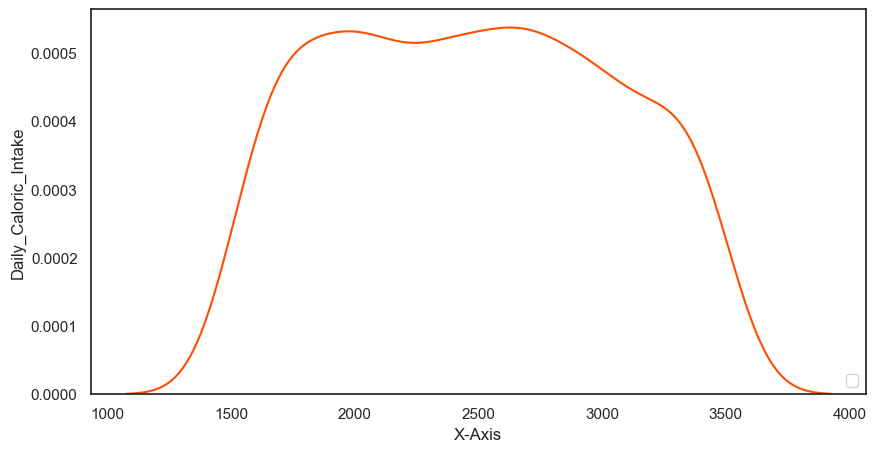

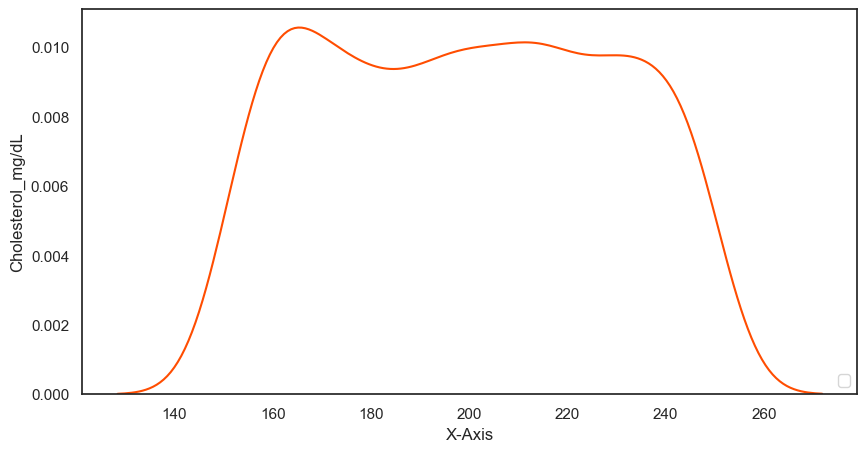

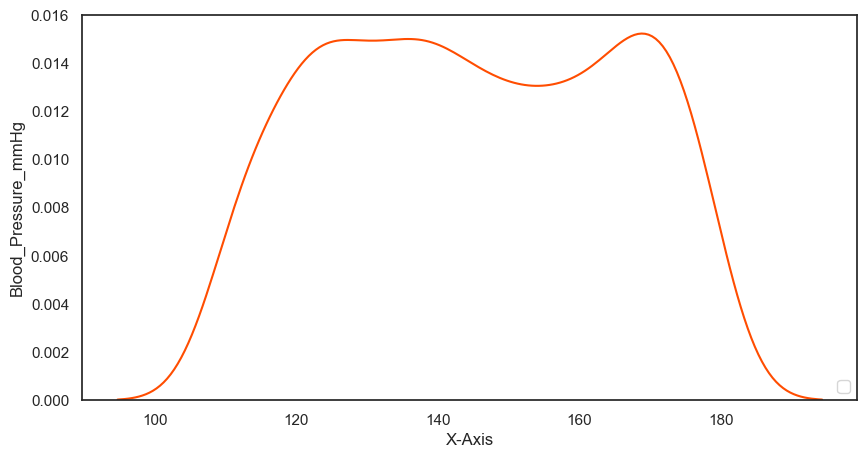

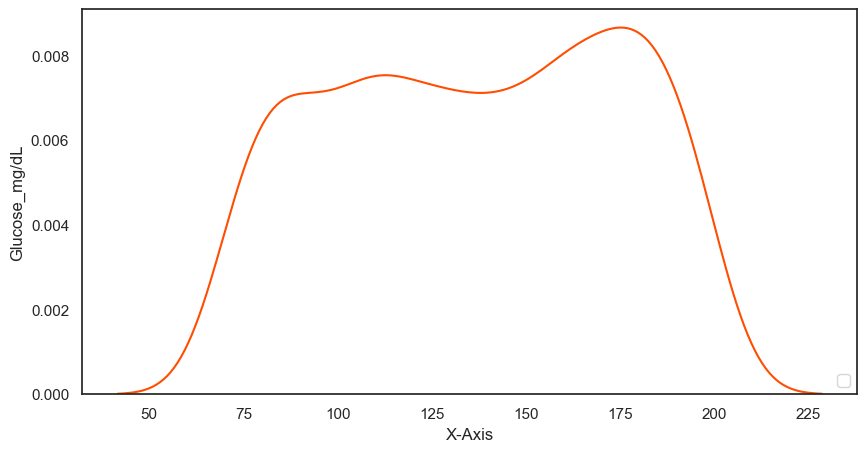

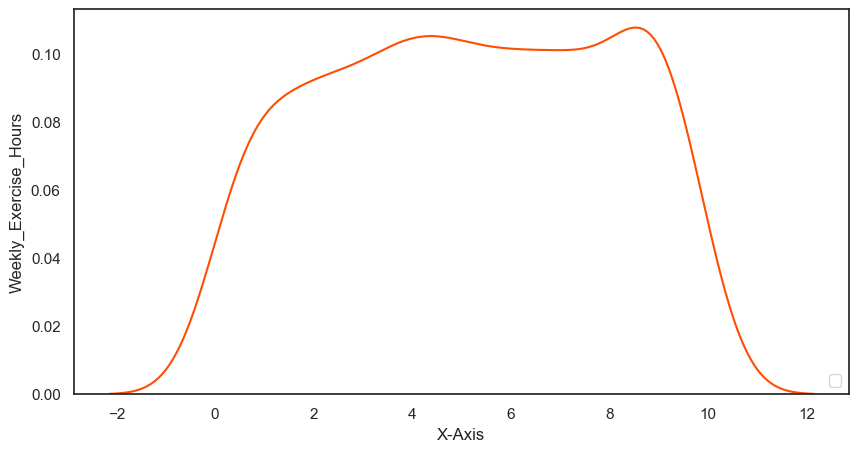

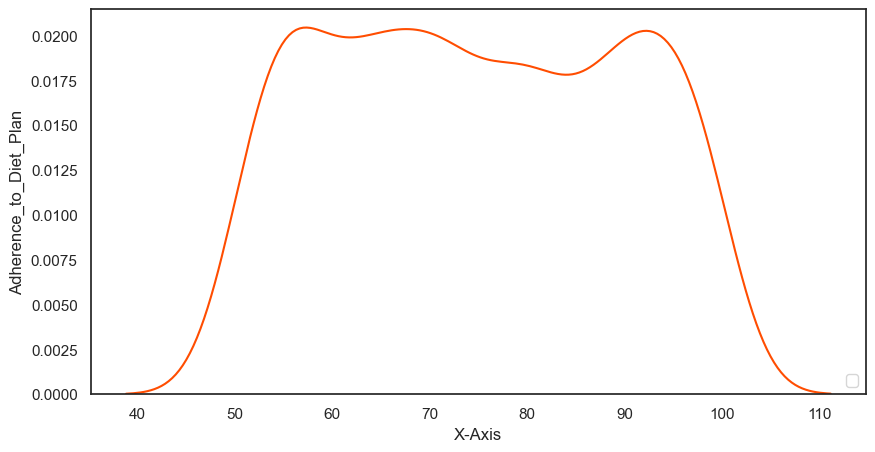

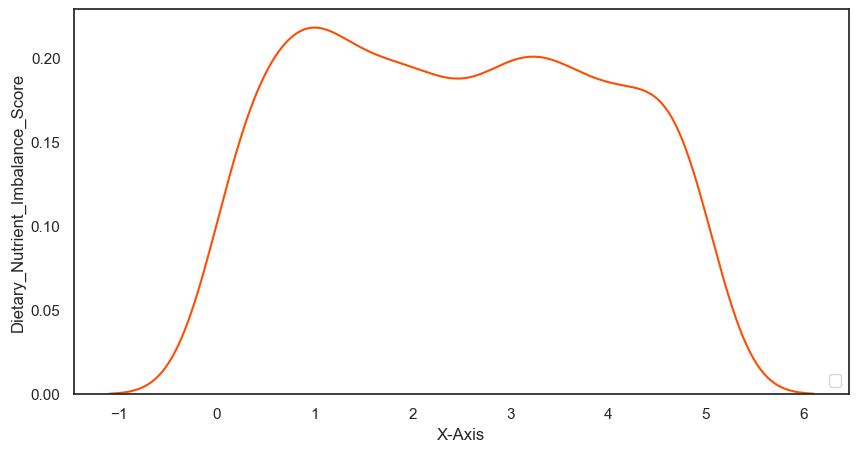

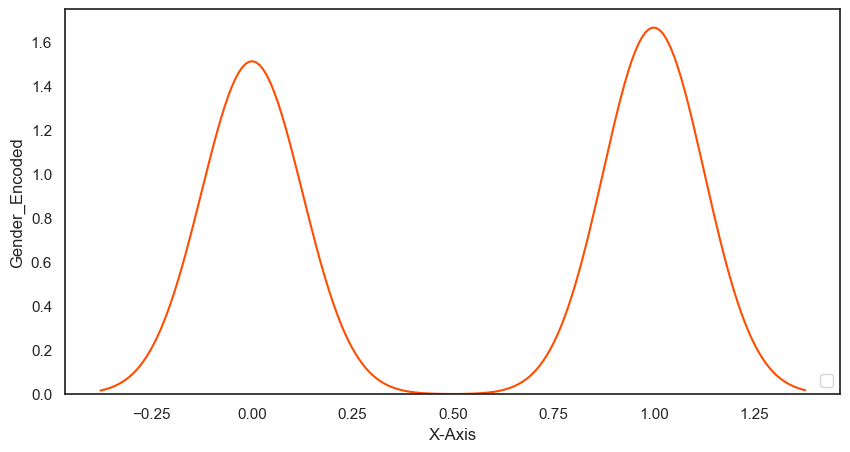

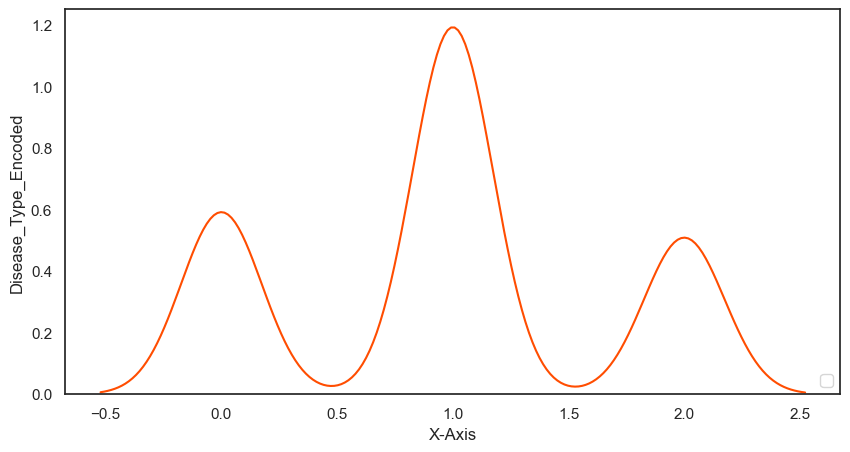

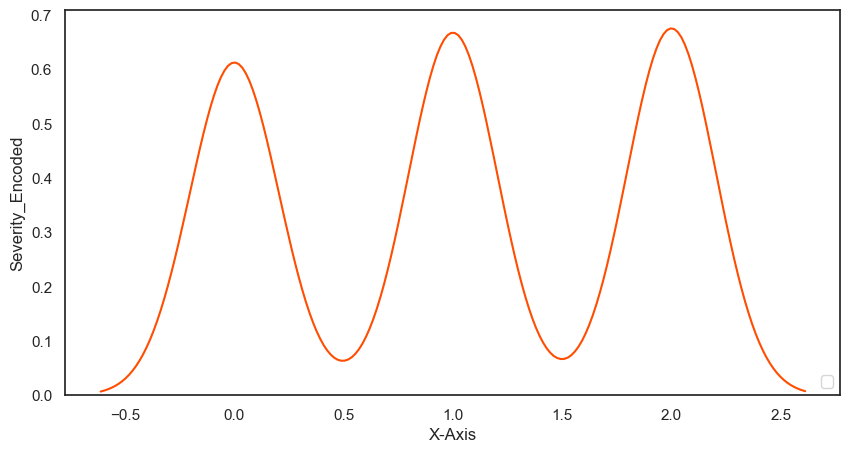

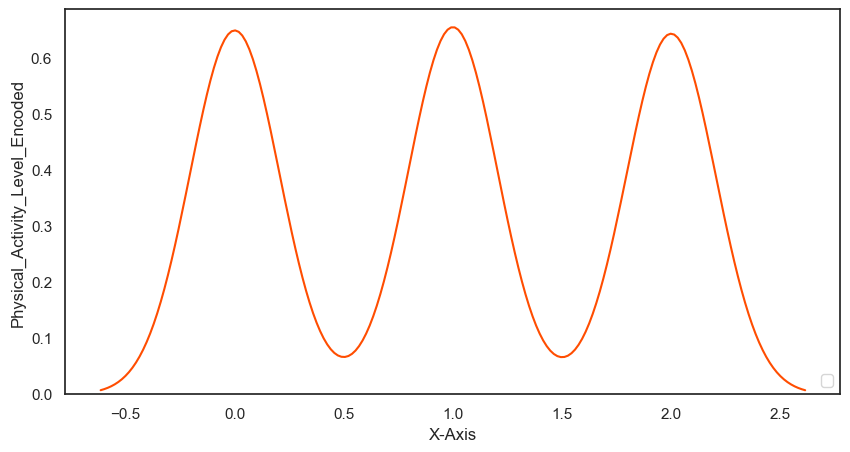

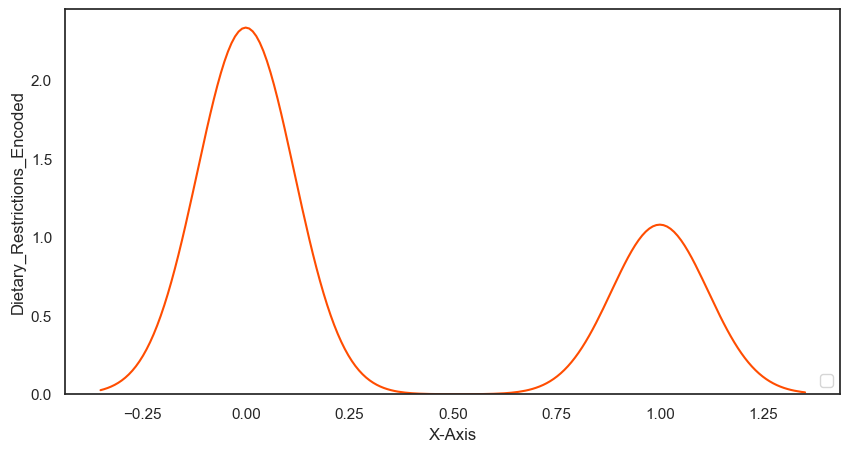

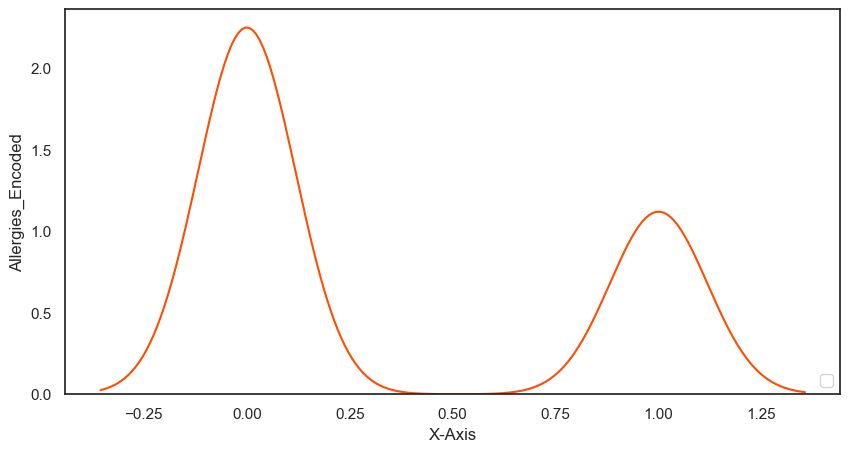

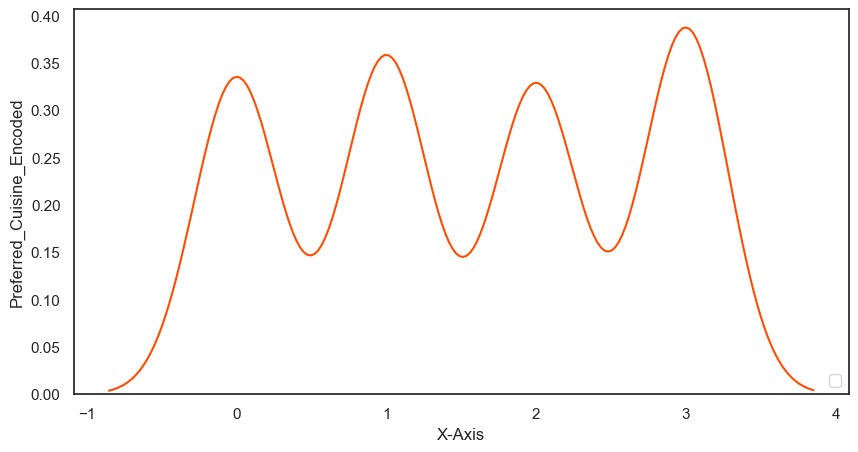

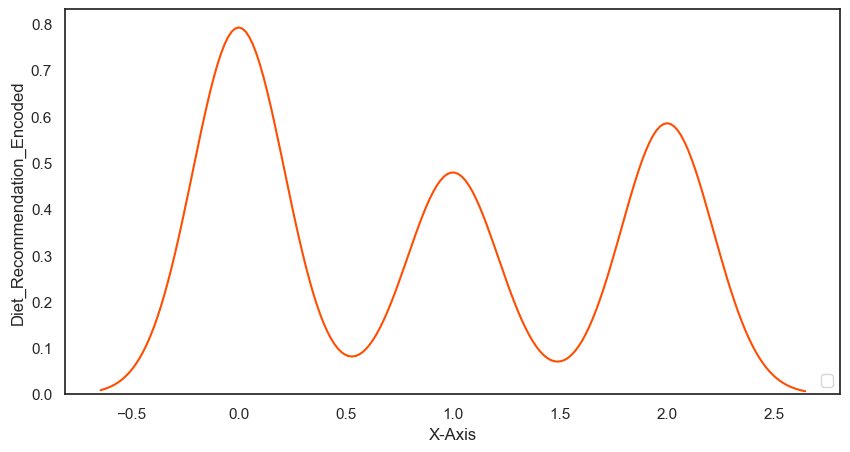

In [39]:
for each_col1 in df3.columns:
    plt.figure(figsize=(10,5))
    plt.subplot()
    sns.set_theme(style='white')
    sns.kdeplot(df3[each_col1],color='#ff4d01')
    plt.xlabel("X-Axis")
    plt.ylabel(each_col1)


    plt.legend(loc="lower right")
    plt.subplots_adjust(wspace=2,hspace=2)
    plt.show()
    

In [40]:
df3.columns

Index(['Age', 'Weight_kg', 'Height_cm', 'BMI', 'Daily_Caloric_Intake',
       'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL',
       'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan',
       'Dietary_Nutrient_Imbalance_Score', 'Gender_Encoded',
       'Disease_Type_Encoded', 'Severity_Encoded',
       'Physical_Activity_Level_Encoded', 'Dietary_Restrictions_Encoded',
       'Allergies_Encoded', 'Preferred_Cuisine_Encoded',
       'Diet_Recommendation_Encoded'],
      dtype='object')

In [41]:
df3.sample(10)

,Age,Weight_kg,Height_cm,BMI,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Gender_Encoded,Disease_Type_Encoded,Severity_Encoded,Physical_Activity_Level_Encoded,Dietary_Restrictions_Encoded,Allergies_Encoded,Preferred_Cuisine_Encoded,Diet_Recommendation_Encoded
767,52,65.9,152,28.5,3045,213.8,124,77.3,9.5,77.2,3.4,0,0,2,1,0,0,1,1
854,39,74.0,166,26.9,1621,204.1,134,147.6,3.7,79.7,0.3,1,2,0,1,0,0,0,0
38,44,52.6,190,14.6,2816,160.7,128,95.4,9.1,97.7,2.5,1,1,1,1,0,0,0,0
974,63,77.9,184,23.0,2643,201.7,142,157.2,1.7,92.8,0.7,0,1,1,1,0,0,2,0
752,35,116.9,168,41.4,3447,190.0,176,191.9,7.0,70.0,2.9,0,0,1,1,0,1,1,1
844,19,102.7,188,29.1,2881,177.4,151,83.4,0.3,63.4,0.5,1,1,1,1,0,1,2,0
907,62,111.2,172,37.6,3428,244.1,126,77.7,5.5,84.1,3.7,1,0,0,0,1,1,1,1
283,66,92.9,163,35.0,2088,241.0,118,86.5,4.0,86.2,0.7,1,2,2,2,1,0,3,0
215,45,100.0,167,35.9,2381,180.4,141,88.9,2.4,78.8,0.3,1,0,2,0,0,0,0,1
828,26,84.7,187,24.2,2177,153.8,122,70.7,7.0,58.9,0.8,1,2,0,2,0,0,3,0


In [42]:
cols=['Age', 'Weight_kg', 'Height_cm', 'BMI', 'Daily_Caloric_Intake',
       'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL',
       'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan',
       'Dietary_Nutrient_Imbalance_Score']

In [43]:
df2.sample(10)

,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Disease_Type,Severity,Physical_Activity_Level,Daily_Caloric_Intake,...,Diet_Recommendation,Patient_ID_Encoded,Gender_Encoded,Disease_Type_Encoded,Severity_Encoded,Physical_Activity_Level_Encoded,Dietary_Restrictions_Encoded,Allergies_Encoded,Preferred_Cuisine_Encoded,Diet_Recommendation_Encoded
910,P0911,38,Male,57.3,157,23.2,Obesity,Moderate,Active,2222,...,Balanced,910,1,2,1,0,0,0,1,0
228,P0229,47,Female,113.8,182,34.4,Obesity,Severe,Active,1842,...,Balanced,228,0,2,2,0,1,0,0,0
650,P0651,65,Female,94.0,198,24.0,Hypertension,Severe,Moderate,3233,...,Low_Sodium,650,0,1,2,1,0,1,1,2
231,P0232,75,Female,82.3,183,24.6,Hypertension,Severe,Moderate,1638,...,Low_Sodium,231,0,1,2,1,1,1,3,2
32,P0033,75,Female,76.9,182,23.2,Hypertension,Mild,Moderate,1691,...,Low_Sodium,32,0,1,0,1,0,0,3,2
510,P0511,26,Female,90.7,159,35.9,Hypertension,Moderate,Active,1977,...,Low_Sodium,510,0,1,1,0,1,1,3,2
776,P0777,39,Male,102.2,184,30.2,Hypertension,Severe,Active,2669,...,Low_Sodium,776,1,1,2,0,1,1,3,2
101,P0102,79,Female,53.1,172,17.9,Hypertension,Moderate,Active,2790,...,Low_Sodium,101,0,1,1,0,0,0,2,2
461,P0462,45,Male,76.3,157,31.0,Diabetes,Severe,Active,2358,...,Low_Carb,461,1,0,2,0,0,1,1,1
401,P0402,52,Male,57.2,161,22.1,Hypertension,Severe,Moderate,3109,...,Low_Sodium,401,1,1,2,1,0,0,2,2


In [44]:
df3.sample(10)

,Age,Weight_kg,Height_cm,BMI,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Gender_Encoded,Disease_Type_Encoded,Severity_Encoded,Physical_Activity_Level_Encoded,Dietary_Restrictions_Encoded,Allergies_Encoded,Preferred_Cuisine_Encoded,Diet_Recommendation_Encoded
355,52,56.8,150,25.2,1835,150.9,163,172.4,9.0,52.5,1.0,1,0,1,1,0,0,3,1
134,26,57.4,152,24.8,2178,208.8,140,129.7,1.6,94.1,2.1,1,0,0,1,0,0,2,1
848,55,57.6,163,21.7,2157,150.7,169,97.3,9.3,73.7,1.7,0,1,0,2,0,0,3,2
421,73,63.2,187,18.1,1714,214.8,163,74.6,2.4,82.7,2.1,1,1,2,0,1,0,0,2
692,50,89.5,166,32.5,2202,219.2,149,194.1,3.2,98.4,0.0,1,1,1,0,0,0,2,2
462,47,70.8,194,18.8,2355,198.4,123,149.4,3.6,85.5,1.1,0,1,2,0,0,0,3,2
698,29,70.8,160,27.7,2540,220.3,125,159.0,1.5,93.9,2.1,1,1,2,1,1,1,2,2
980,22,52.5,193,14.1,2859,212.3,156,196.0,3.6,60.5,2.9,0,2,2,1,1,0,0,0
768,58,112.3,159,44.4,2570,185.0,117,182.9,6.1,61.9,2.7,1,2,2,1,0,1,2,0
316,28,55.7,163,21.0,2259,242.9,170,162.0,5.3,82.0,1.1,0,1,1,1,1,0,3,0


In [45]:
df3.columns

Index(['Age', 'Weight_kg', 'Height_cm', 'BMI', 'Daily_Caloric_Intake',
       'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL',
       'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan',
       'Dietary_Nutrient_Imbalance_Score', 'Gender_Encoded',
       'Disease_Type_Encoded', 'Severity_Encoded',
       'Physical_Activity_Level_Encoded', 'Dietary_Restrictions_Encoded',
       'Allergies_Encoded', 'Preferred_Cuisine_Encoded',
       'Diet_Recommendation_Encoded'],
      dtype='object')

In [46]:
x=df3[['Age', 'Weight_kg', 'Height_cm', 'BMI', 'Daily_Caloric_Intake',
       'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL',
       'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan',
       'Dietary_Nutrient_Imbalance_Score', 'Gender_Encoded','Severity_Encoded',
       'Physical_Activity_Level_Encoded', 'Dietary_Restrictions_Encoded',
       'Allergies_Encoded', 'Preferred_Cuisine_Encoded',
       'Diet_Recommendation_Encoded']]
y=df3['Disease_Type_Encoded'].squeeze()

In [47]:
featuresSelections=SelectKBest(score_func=f_classif,k=10)
featuresSelections

,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...001A11B4A1300>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",10


In [48]:
fitting_selection=featuresSelections.fit(x,y)
fitting_selection

,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...001A11B4A1300>
,"k k: int or ""all"", default=10Number of top features to select.The ""all"" option bypasses selection, for use in a parameter search.",10


In [49]:
which_features_selected=x.columns[featuresSelections.get_support()]
which_features_selected

Index(['Age', 'Weight_kg', 'Height_cm', 'BMI', 'Blood_Pressure_mmHg',
       'Gender_Encoded', 'Physical_Activity_Level_Encoded',
       'Dietary_Restrictions_Encoded', 'Allergies_Encoded',
       'Diet_Recommendation_Encoded'],
      dtype='object')

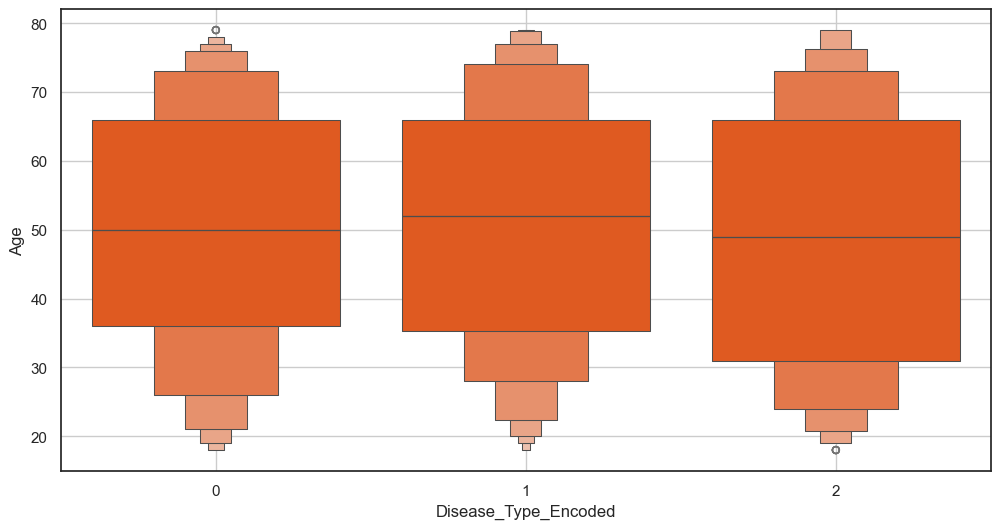

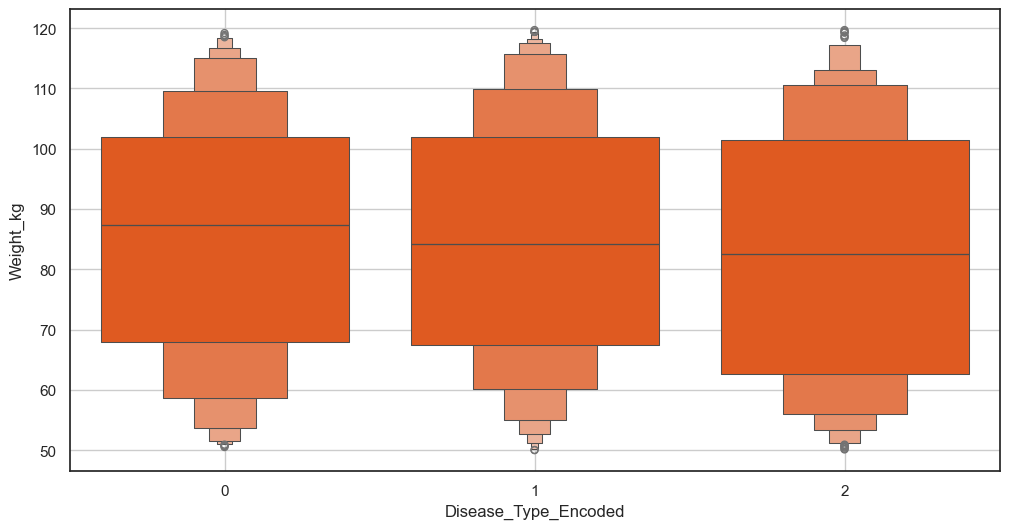

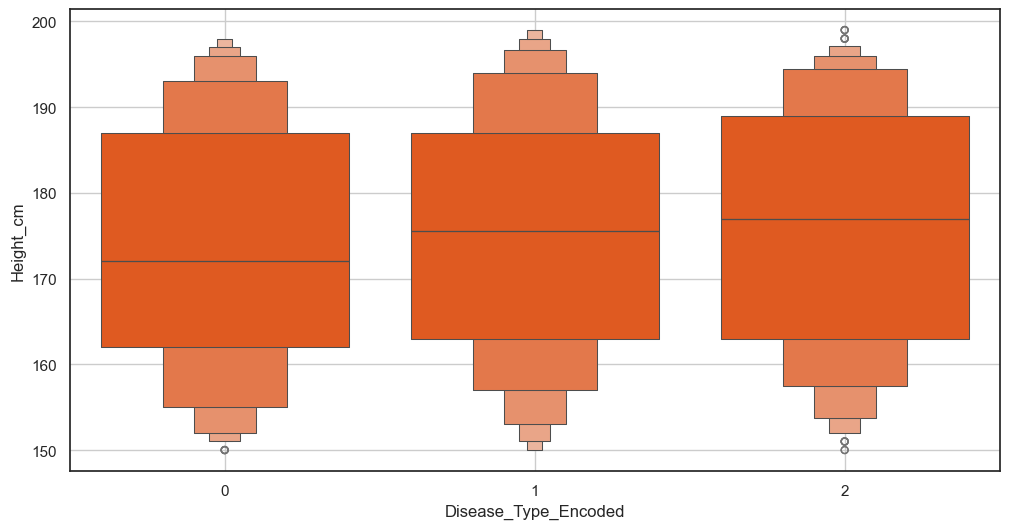

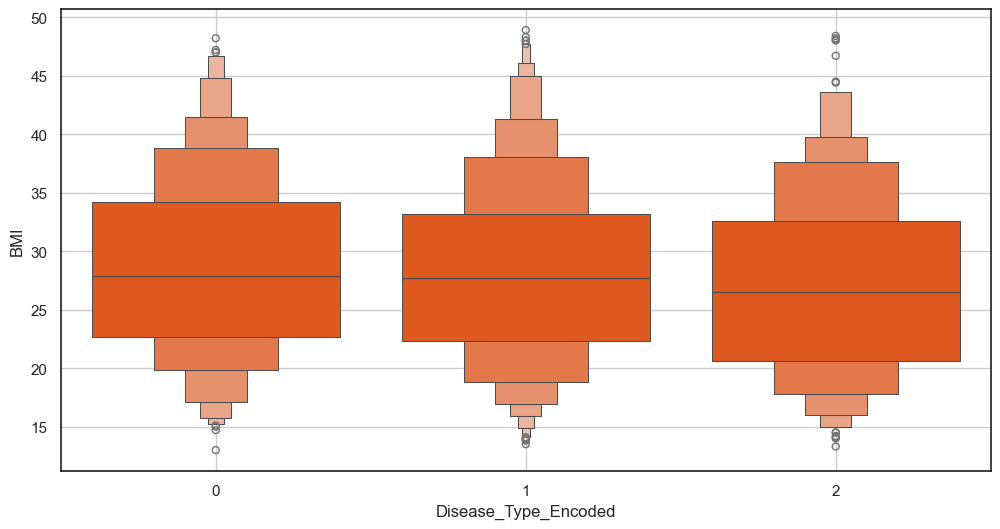

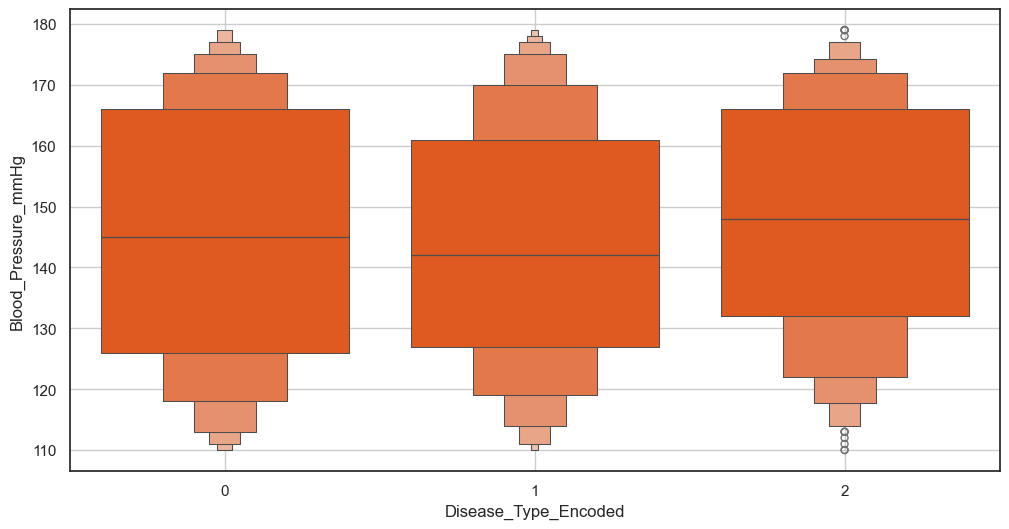

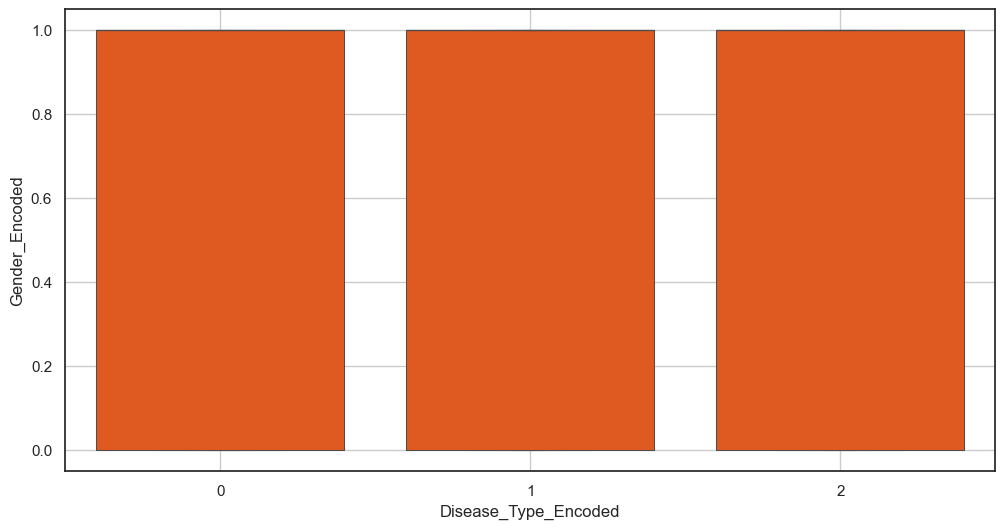

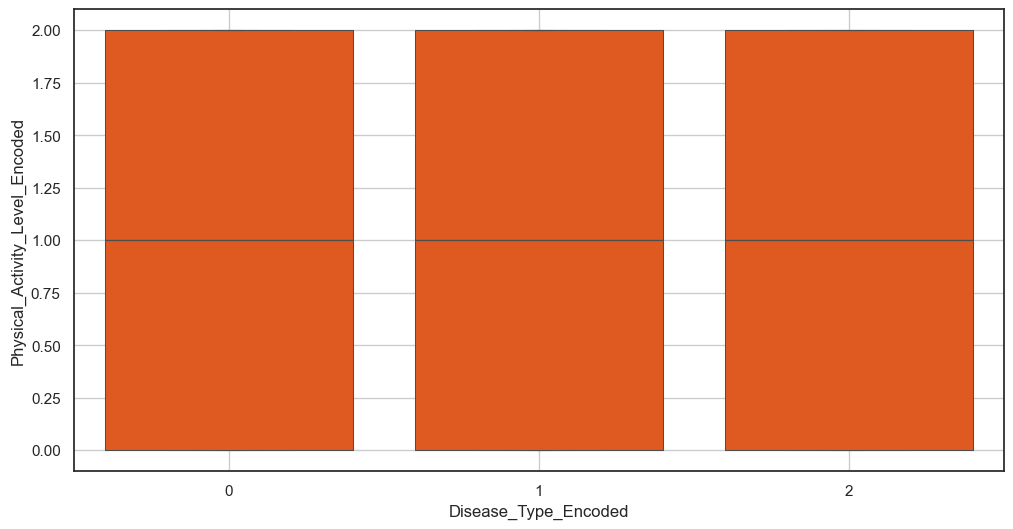

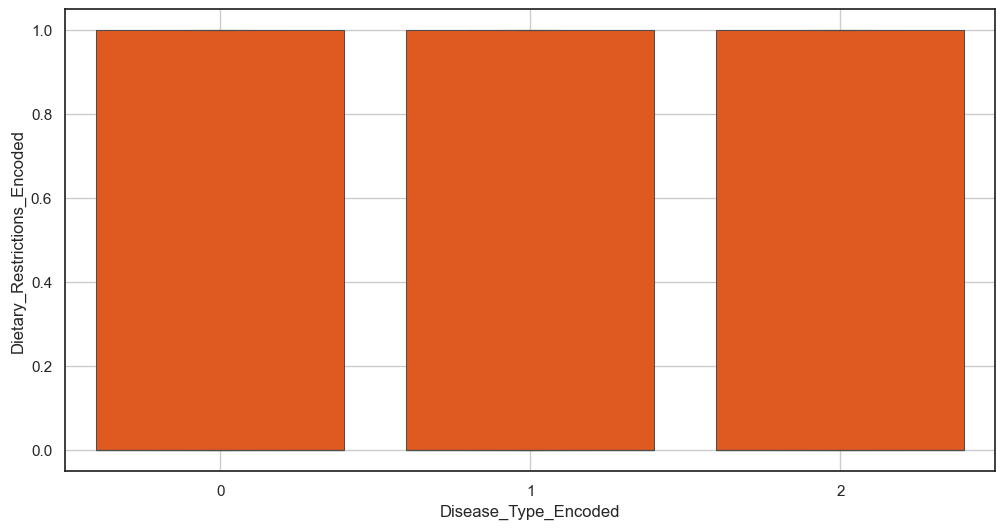

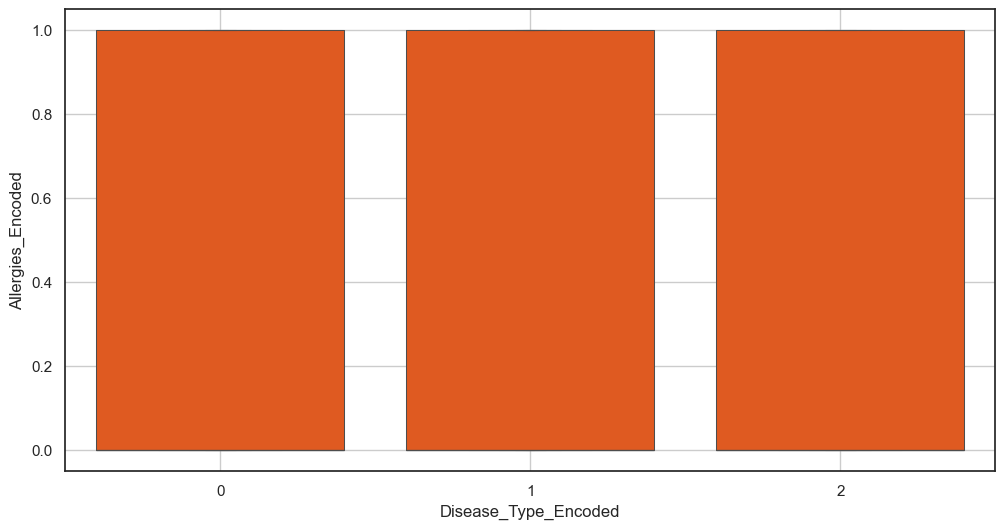

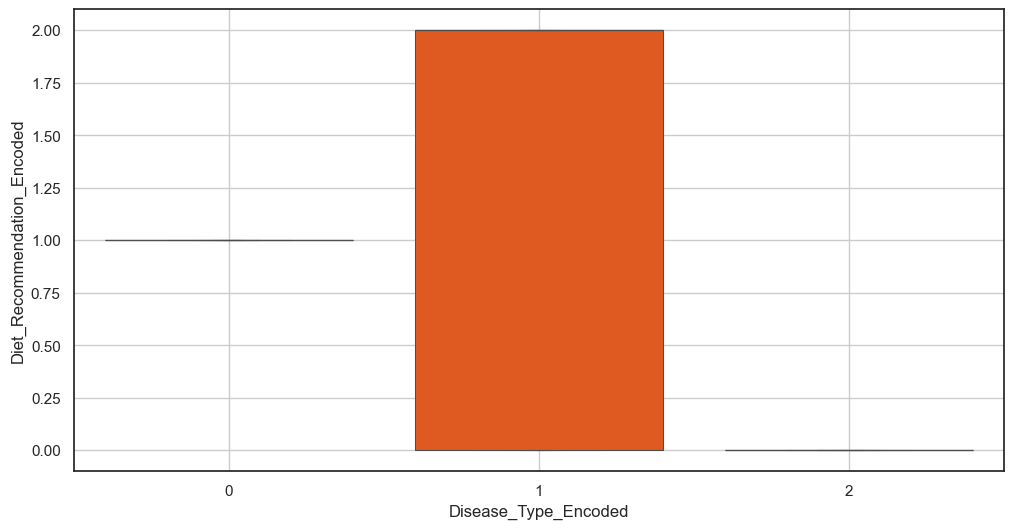

In [50]:
for each_col in which_features_selected:
    plt.figure(figsize=(12,6))
    cl1=['#ff4d01','#000000']
    sns.boxenplot(data=df3,x=df3['Disease_Type_Encoded'],y=each_col,color='#ff4d01')
    plt.savefig(f"{each_col}_boxenplot.png",dpi=100)
    plt.grid(True)
    plt.show()

In [51]:
x1=df3[['Age', 'Weight_kg', 'Height_cm', 'BMI', 'Blood_Pressure_mmHg',
       'Gender_Encoded', 'Physical_Activity_Level_Encoded',
       'Dietary_Restrictions_Encoded', 'Allergies_Encoded',
       'Diet_Recommendation_Encoded']]
y1=df3['Disease_Type_Encoded'].squeeze()

In [52]:
x_train,x_test,y_train,y_test=train_test_split(x1,y1,random_state=42,test_size=0.20)

In [53]:
logistic_regression=LogisticRegression(solver="lbfgs",n_jobs=1)
logistic_regression

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [54]:
logistic_regression.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [55]:
cross_val_score_logistic=cross_val_score(logistic_regression,x,y,scoring='accuracy',cv=50)
print(cross_val_score_logistic)
mean_logistic_regression=np.mean(cross_val_score_logistic)
print(mean_logistic_regression)

[0.5        0.5        0.5        0.5        0.5        0.5
 0.5        0.45       0.5        0.45       0.4        0.5
 0.5        0.5        0.5        0.5        0.5        0.5
 0.5        0.5        0.5        0.5        0.5        0.45
 0.5        0.5        0.5        0.5        0.55       0.55
 0.55       0.5        0.55       0.55       0.5        0.55
 0.55       0.55       0.55       0.55       0.55       0.55
 0.55       0.55       0.55       0.55       0.52631579 0.52631579
 0.52631579 0.52631579]
0.5131052631578947


In [56]:
DecisionTreeClassifier_instance=DecisionTreeClassifier(splitter='best',max_depth=10,min_samples_leaf=10,min_samples_split=20,max_features='sqrt',criterion='gini')
DecisionTreeClassifier_instance


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cur

In [57]:
DecisionTreeClassifier_instance.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cur

In [58]:
cross_val_score_decision=cross_val_score(DecisionTreeClassifier_instance,x1,y1,scoring='accuracy',cv=50)
print(cross_val_score_decision)
mean_decisio_regression=np.mean(cross_val_score_decision)
print(mean_decisio_regression)

[0.6        0.75       0.6        0.45       0.75       0.6
 0.7        0.45       0.7        0.75       0.5        0.7
 0.9        0.75       0.9        0.65       0.65       0.5
 0.8        0.7        0.8        0.85       0.6        0.85
 0.7        0.85       0.45       0.6        0.75       0.85
 0.8        0.75       0.65       0.65       0.9        0.75
 0.65       0.65       0.65       0.75       0.6        0.85
 0.8        0.7        0.75       0.85       0.68421053 0.78947368
 0.73684211 0.84210526]
0.7100526315789475


In [59]:
params_grid={'criterion':['gini','entropy'],"max_depth":[2,4,6,8,10],"min_samples_split":[2,4,6,10,15,20,30,50,100]}


deceiosn_tree_search_cv=GridSearchCV(n_jobs=-1,estimator=DecisionTreeClassifier_instance,param_grid=params_grid,scoring='accuracy',cv=100)
deceiosn_tree_search_cv

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ples_split=20)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'min_samples_split': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",100
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

In [60]:
RandomForestClassifier_Instance=RandomForestClassifier(n_estimators=100,n_jobs=-1,max_depth=10,min_samples_leaf=10,min_samples_split=20,max_features='sqrt',criterion='gini')
RandomForestClassifier_Instance

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [61]:
RandomForestClassifier_Instance.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [62]:
params_grid={'criterion':['gini','entropy'],"max_depth":[2,4,6,8,10],"min_samples_split":[2,4,6,10,15,20,30,50,100]}

deceiosn_tree_search_cv=GridSearchCV(n_jobs=-1,estimator=DecisionTreeClassifier_instance,param_grid=params_grid,scoring='accuracy',cv=100)
deceiosn_tree_search_cv

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ples_split=20)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'min_samples_split': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",100
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

In [63]:
x1.columns

Index(['Age', 'Weight_kg', 'Height_cm', 'BMI', 'Blood_Pressure_mmHg',
       'Gender_Encoded', 'Physical_Activity_Level_Encoded',
       'Dietary_Restrictions_Encoded', 'Allergies_Encoded',
       'Diet_Recommendation_Encoded'],
      dtype='object')

In [64]:
cross_val_score_random=cross_val_score(RandomForestClassifier_Instance,x1,y1,scoring='accuracy',cv=50)
print(cross_val_score_random)
mean_random_regression=np.mean(cross_val_score_random)
print(mean_random_regression)

[0.8        0.7        0.8        0.7        0.75       0.85
 0.95       0.7        0.7        0.7        0.75       0.75
 0.85       0.8        0.8        0.8        0.85       0.75
 0.9        0.75       0.85       0.9        0.75       0.75
 0.8        0.95       0.7        0.65       0.85       0.85
 0.8        0.8        0.9        0.85       0.9        0.8
 0.7        0.75       0.75       0.9        0.8        0.9
 0.7        0.9        0.8        0.9        0.78947368 0.89473684
 0.84210526 0.89473684]
0.8054210526315789


In [65]:
KNeighborsClassifier_instance=KNeighborsClassifier(n_jobs=-1,n_neighbors=10,weights='distance',algorithm='auto')
KNeighborsClassifier_instance

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [66]:
KNeighborsClassifier_instance.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


In [67]:
cross_val_score_knn=cross_val_score(KNeighborsClassifier_instance,x1,y1,scoring='accuracy',cv=50)
print(cross_val_score_knn)
mean_knn_regression=np.mean(cross_val_score_knn)
print(mean_knn_regression)

[0.3        0.4        0.4        0.5        0.55       0.35
 0.5        0.6        0.35       0.3        0.35       0.4
 0.3        0.45       0.35       0.35       0.5        0.35
 0.4        0.5        0.65       0.45       0.6        0.6
 0.45       0.5        0.4        0.25       0.4        0.45
 0.45       0.3        0.45       0.3        0.55       0.5
 0.35       0.6        0.45       0.4        0.45       0.4
 0.4        0.5        0.45       0.4        0.36842105 0.57894737
 0.47368421 0.47368421]
0.43589473684210517


In [68]:
SVCClassifier_instance=SVC(C=1,kernel='rbf')
SVCClassifier_instance

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [69]:
SVCClassifier_instance.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [70]:
cross_val_score_svc=cross_val_score(SVCClassifier_instance,x,y,scoring='accuracy',cv=50)
print(cross_val_score_svc)
mean_svc_regression=np.mean(cross_val_score_svc)
print(mean_svc_regression)

[0.5        0.5        0.5        0.5        0.5        0.5
 0.5        0.5        0.5        0.5        0.5        0.5
 0.5        0.5        0.5        0.5        0.5        0.5
 0.5        0.5        0.5        0.5        0.5        0.5
 0.5        0.5        0.5        0.5        0.55       0.55
 0.55       0.55       0.55       0.55       0.55       0.55
 0.55       0.55       0.55       0.55       0.55       0.55
 0.55       0.55       0.55       0.55       0.52631579 0.52631579
 0.52631579 0.52631579]
0.5201052631578947


In [71]:
x1.describe()

,Age,Weight_kg,Height_cm,BMI,Blood_Pressure_mmHg,Gender_Encoded,Physical_Activity_Level_Encoded,Dietary_Restrictions_Encoded,Allergies_Encoded,Diet_Recommendation_Encoded
count,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000
mean,49.865462,84.470181,174.913655,28.097189,145.044177,0.524096,0.996988,0.316265,0.332329,0.888554
std,18.106385,20.019180,14.280907,7.916558,20.248061,0.499670,0.815054,0.465251,0.471285,0.854565
min,18.000000,50.000000,150.000000,13.000000,110.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,66.575000,163.000000,22.000000,128.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,50.000000,85.050000,175.000000,27.350000,145.000000,1.000000,1.000000,0.000000,0.000000,1.000000
75%,66.000000,101.825000,187.000000,33.325000,163.250000,1.000000,2.000000,1.000000,1.000000,2.000000
max,79.000000,119.700000,199.000000,48.900000,179.000000,1.000000,2.000000,1.000000,1.000000,2.000000


x1=df3[['Age', 'Weight_kg', 'Height_cm', 'BMI', 'Blood_Pressure_mmHg',
       'Gender_Encoded', 'Physical_Activity_Level_Encoded',
       'Dietary_Restrictions_Encoded', 'Allergies_Encoded',
       'Diet_Recommendation_Encoded']]
y1=df3['Disease_Type_Encoded'].squeeze()

logistic_regression
DecisionTreeClassifier_instance
RandomForestClassifier_Instance
KNeighborsClassifier_instance
SVCClassifier_instance



In [72]:
x1.describe()

,Age,Weight_kg,Height_cm,BMI,Blood_Pressure_mmHg,Gender_Encoded,Physical_Activity_Level_Encoded,Dietary_Restrictions_Encoded,Allergies_Encoded,Diet_Recommendation_Encoded
count,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000,996.000000
mean,49.865462,84.470181,174.913655,28.097189,145.044177,0.524096,0.996988,0.316265,0.332329,0.888554
std,18.106385,20.019180,14.280907,7.916558,20.248061,0.499670,0.815054,0.465251,0.471285,0.854565
min,18.000000,50.000000,150.000000,13.000000,110.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,66.575000,163.000000,22.000000,128.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,50.000000,85.050000,175.000000,27.350000,145.000000,1.000000,1.000000,0.000000,0.000000,1.000000
75%,66.000000,101.825000,187.000000,33.325000,163.250000,1.000000,2.000000,1.000000,1.000000,2.000000
max,79.000000,119.700000,199.000000,48.900000,179.000000,1.000000,2.000000,1.000000,1.000000,2.000000


In [73]:
df2[['Disease_Type','Disease_Type_Encoded']].value_counts().to_dict()

{('Hypertension', 1): 520, ('Diabetes', 0): 258, ('Obesity', 2): 222}

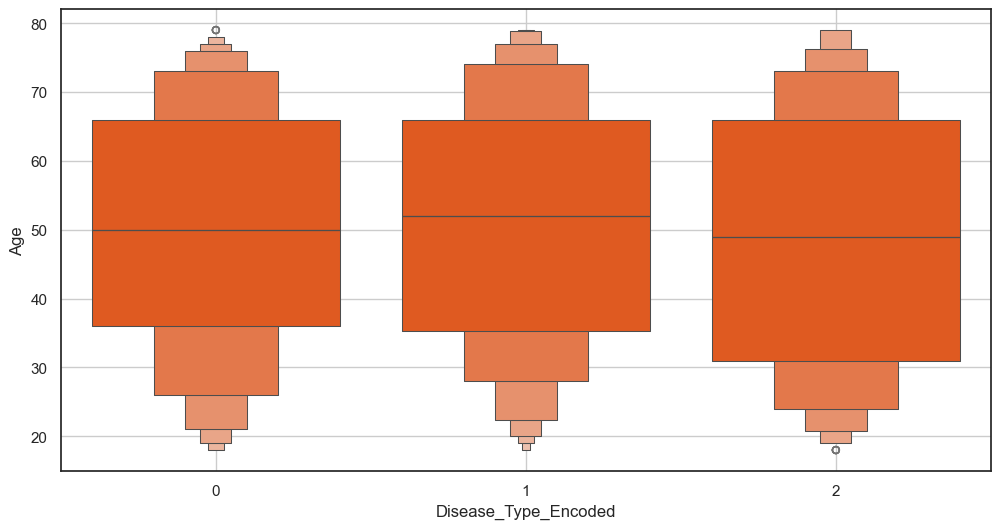

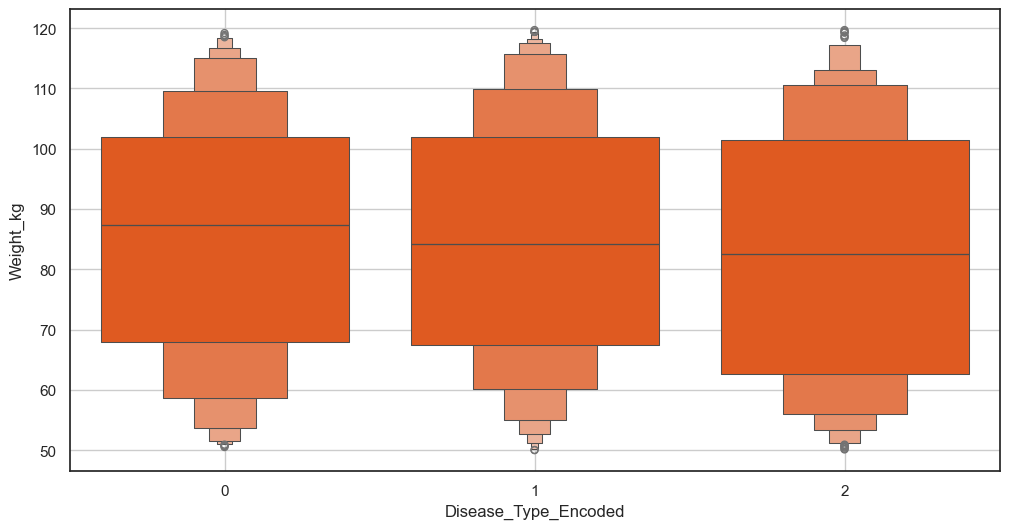

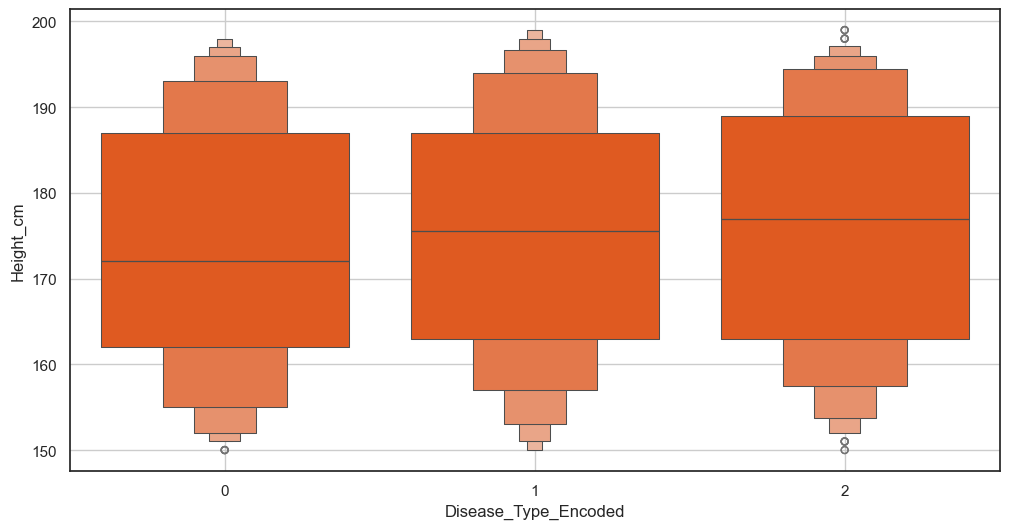

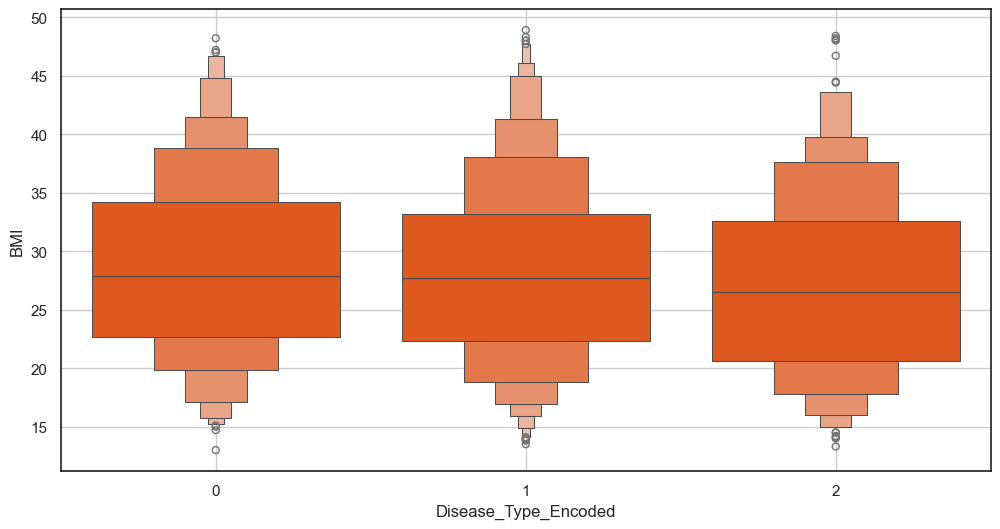

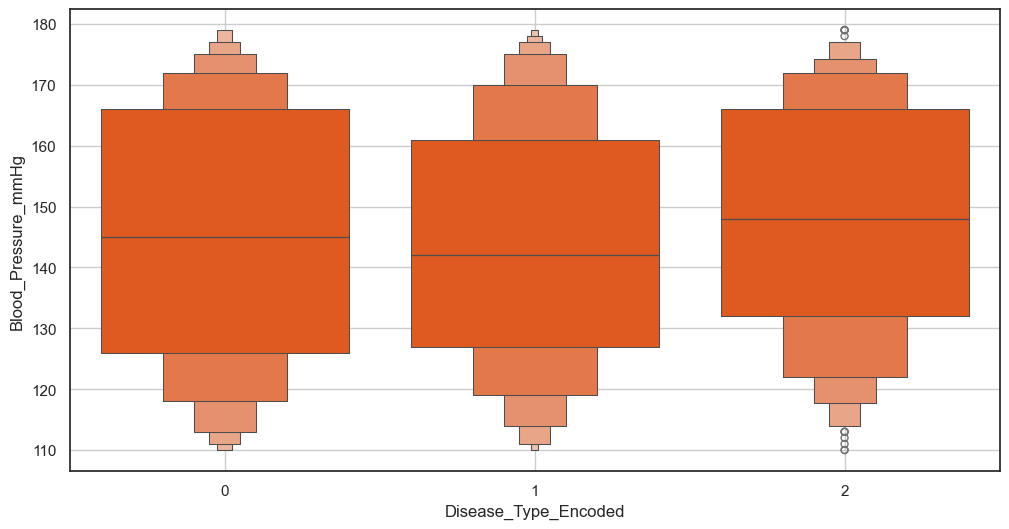

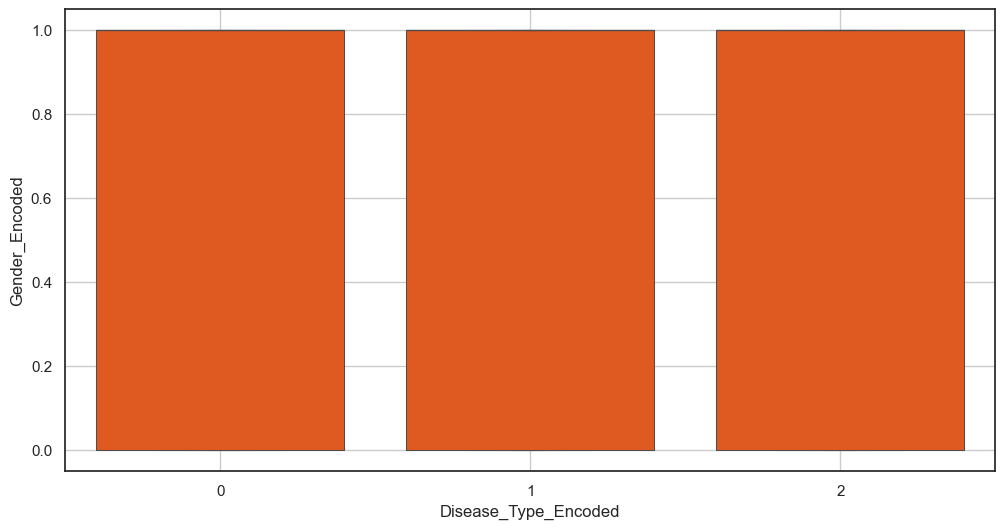

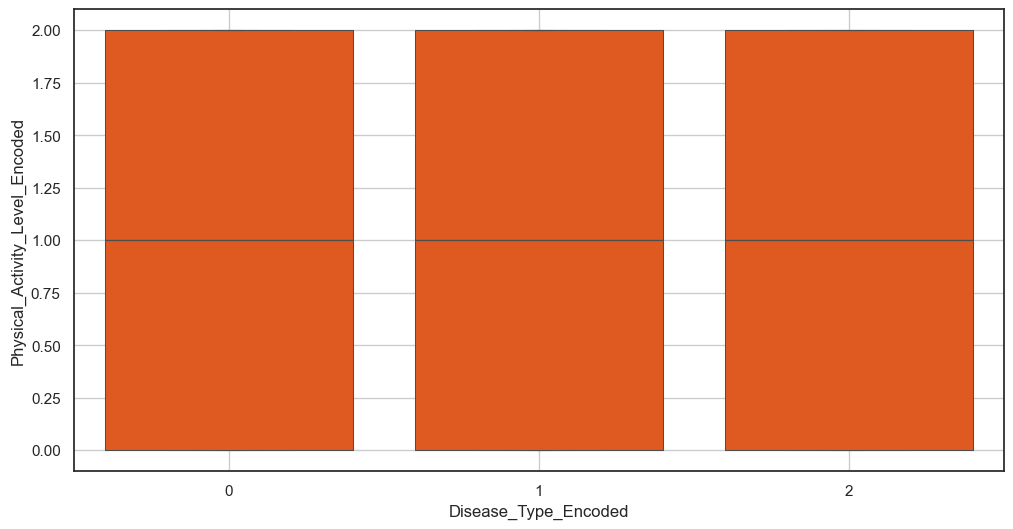

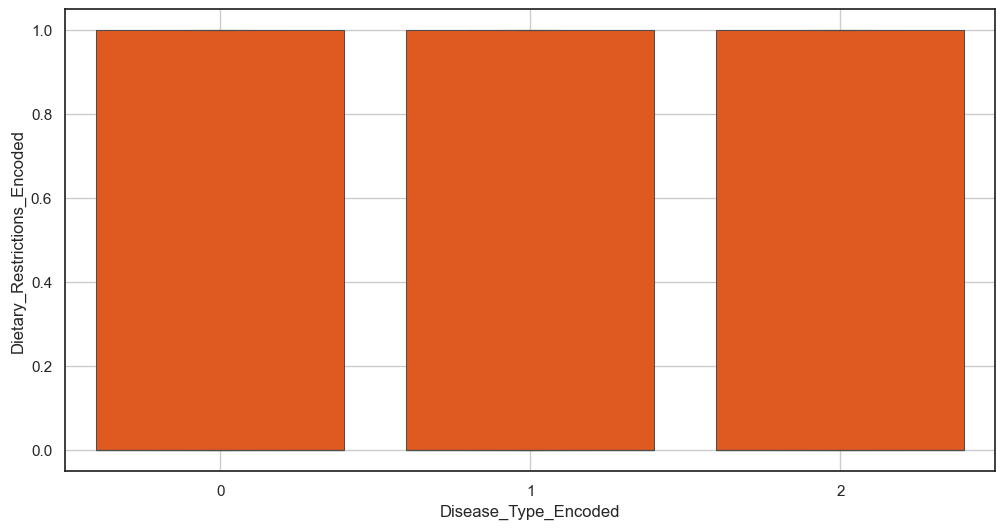

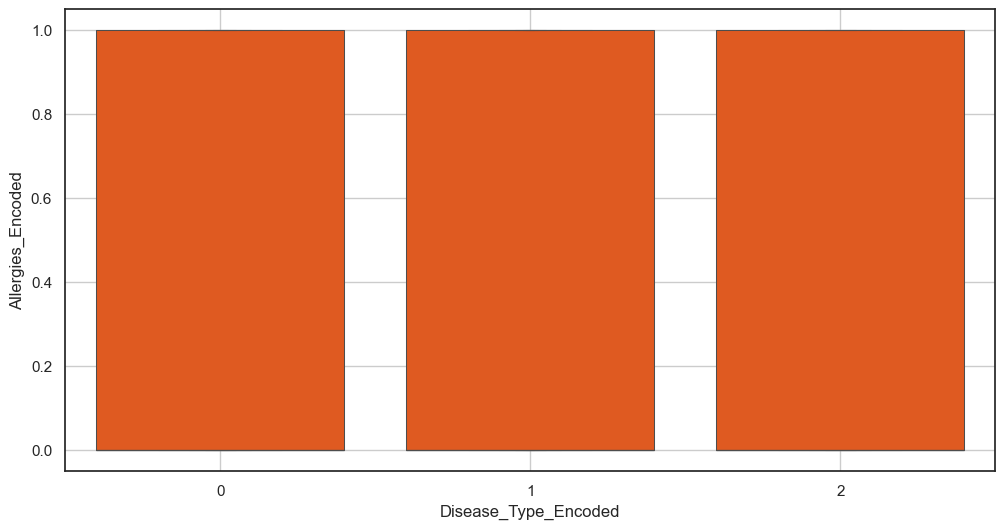

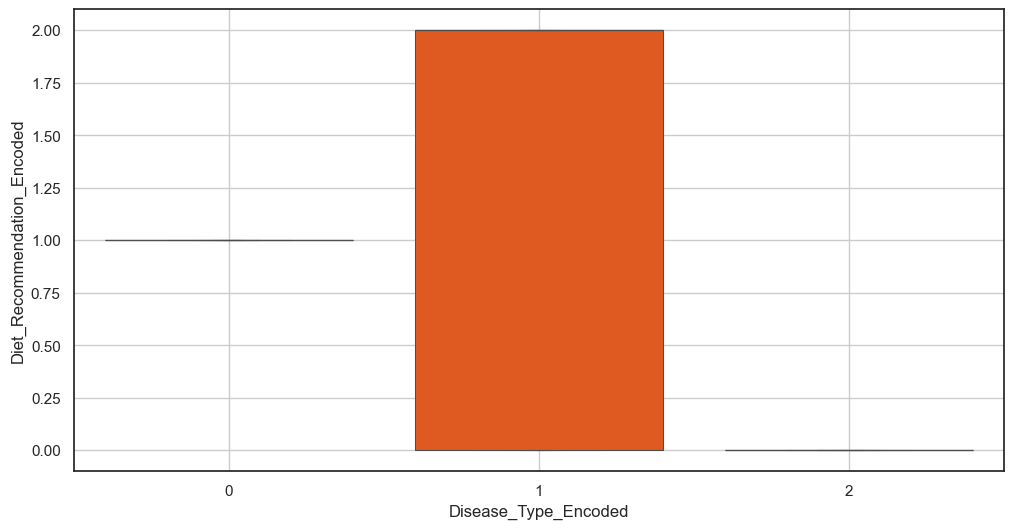

In [74]:
for each_col in which_features_selected:
    plt.figure(figsize=(12,6),facecolor='#ffffff')
    sns.boxenplot(data=df3,x=df3['Disease_Type_Encoded'],y=each_col,color='#ff4d01')
    plt.savefig(f"{each_col}_boxenplot.png",dpi=100)
    plt.grid(True)
    plt.show()

In [75]:
import joblib

joblib.dump(logistic_regression,"../Frontend/pages/logistic_regression.joblib")

['../Frontend/pages/logistic_regression.joblib']

In [76]:

joblib.dump(RandomForestClassifier_Instance,"../Frontend/pages/RandomForestClassifier_Instance.joblib")

['../Frontend/pages/RandomForestClassifier_Instance.joblib']

In [77]:

joblib.dump(KNeighborsClassifier_instance,"../Frontend/pages/KNeighborsClassifier_instance.joblib")

['../Frontend/pages/KNeighborsClassifier_instance.joblib']

In [78]:

joblib.dump(SVCClassifier_instance,"../Frontend/pages/SVCClassifier_instance.joblib")

['../Frontend/pages/SVCClassifier_instance.joblib']

In [79]:
joblib.dump(DecisionTreeClassifier_instance,"../Frontend/pages/DecisionTreeClassifier_instance.joblib")

['../Frontend/pages/DecisionTreeClassifier_instance.joblib']

In [80]:
# cata_transformer=Pipeline(steps=[
#     ('catagerical_col',OrdinalEncoder(dtype='int'))
# ])
# # print(cata_transformer.named_steps['catagerical_col'])
# num_transfomer=Pipeline(steps=[
#     ('numerical_col',StandardScaler())
# ])
# # print(num_transfomer.named_steps['numerical_col'])
# preprocessor=ColumnTransformer(transformers=[
#          ('cata',cata_transformer,catagerical_col),
#          ('num',num_transfomer,numerical_col)  
# ])
# df2_transform=preprocessor.fit_transform(df2)


In [81]:
# final_pipeline=Pipeline(steps=[
#     ('preprocessor',preprocessor),
#     ('LogisticRegression',LogisticRegression(solver='lbfgs',n_jobs=1)),
#     ("DecisionTreeClassifier",DecisionTreeClassifier(splitter='best',max_depth=10,min_samples_split=10,min_samples_leaf=4,criterion='gini',max_features='sqrt')),
#     ("RandomForestClassifier",RandomForestClassifier(n_estimators=100,max_depth=10,min_samples_split=10,max_features='sqrt',min_samples_leaf=10,criterion='gini',n_jobs=-1)),
#     ("KNeighborsClassifier",KNeighborsClassifier(n_jobs=-1,n_neighbors=10,weights='distance',algorithm='auto')),
#     ("SVC",SVC(C=1,kernel='rbf',random_state=10))
# ])
# print(final_pipeline)